In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
import math
import keyring
import itertools
from ast import literal_eval

In [3]:
from suncalc import get_position, get_times
from datetime import datetime as dt
import pytz

In [4]:
# This is used to avoid hard-coding directories. 
# To set the directory, use the command prompt or a notebook you don't check in.  run:
# import keyring
# keyring.set_password("msp", "vmt_reduction_dir", <directory>)

# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [6]:
# read in the data
df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df

C:\Users\yianz\AppData\Local\Temp\ipykernel_19512\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451969,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
451970,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451971,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451972,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [ ]:
# # # read path geopkg data
# # parquet files take an order of magnitude less time to read
# car = gpd.read_parquet(data_dir + "/Data_Processed/geodata/car.parquet")
# bike = gpd.read_parquet(data_dir + "/Data_Processed/geodata/bike_lts.parquet")
# transit = gpd.read_parquet(data_dir + "/Data_Processed/geodata/transit.parquet")
# walk = gpd.read_parquet(data_dir + "/Data_Processed/geodata/walk.parquet")
# read one at once for performance reasons

In [7]:
transit = gpd.read_parquet(data_dir + "/Data_Processed/geodata/transit.parquet")

In [8]:
car = gpd.read_parquet(data_dir + "/Data_Processed/geodata/car.parquet")

In [12]:
bike = gpd.read_parquet(data_dir + "/Data_Processed/geodata/bike_lts.parquet")

In [13]:
walk = gpd.read_parquet(data_dir + "/Data_Processed/geodata/walk.parquet")

In [ ]:
# transit preprocessing

In [ ]:
# transit has no distance; optimized on duration
# TODO: project to some non-latlon projection and calcaulte
transit.columns

Index(['trip_id', 'leg_index', 'start_time', 'end_time', 'origin_stop_id',
       'origin_stop_name', 'destination_stop_id', 'destination_stop_name',
       'route_id', 'route_short_name', 'route_long_name', 'route_type',
       'leg_type', 'geometry'],
      dtype='object')

In [15]:
df.columns

Index(['Unnamed: 0', 'wave', 'hh_id', 'person_id', 'person_num', 'day_num',
       'linked_trip_id', 'trip_id', 'travel_date', 'travel_dow', 'depart_time',
       'arrive_time', 'duration', 'distance', 'speed_mph', 'vehicle_trips',
       'vmt', 'o_lat', 'o_lon', 'o_bg_2010', 'o_county', 'o_state', 'd_lat',
       'd_lon', 'd_bg_2010', 'd_county', 'd_state', 'mode', 'detailed_mode',
       'o_purpose', 'o_purpose_category', 'd_purpose', 'd_purpose_category',
       'num_travelers', 'num_hh_travelers', 'num_non_hh_travelers',
       'num_unlinked_trips', 'gas_link', 'home_lat', 'home_lon',
       'home_bg_2010', 'home_county', 'home_state', 'income_broad',
       'income_detailed', 'rent_own', 'rent_cost', 'residence_type',
       'num_adults', 'num_kids', 'num_students', 'num_workers', 'num_vehicles',
       'relationship', 'age', 'gender', 'disability', 'education',
       'student_status', 'school_attend', 'employment_status', 'num_jobs',
       'job_type', 'can_drive', 'transportati

In [17]:
# calculate duration from start/eend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [18]:
transit["num_transfers"] = (transit["leg_type"] == "TransitRouter.transfer") # temporary field to calculate number of transfers
transit["non_transit_duration"] = (transit["leg_type"].isin(["TransitRouter.access", "TransitRouter.egress"])) * (transit["duration"]) # non-transit time (access and egress)

In [19]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum",
    "num_transfers": "sum",
    "non_transit_duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [20]:
# 2013 transit trips lack a corresponding path out of 11271 (18%)
# possibly need to relax the optimization restrictions for transfers/other factors
df[(df["mode"] == "Transit") & (~df["trip_id"].isin(transit_grouped["trip_id"]))]

,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
186,190,1,18115411,1811541101,1,3,9.0,"[1811541101009, 1811541101010, 1811541101011, ...",2018-11-28,Wednesday,...,NaN,NaN,NaN,NaN,Yes,Yes,383.703090,383.703090,95.925770,95.925770
190,194,1,18115411,1811541101,1,4,13.0,"[1811541101019, 1811541101020, 1811541101021]",2018-11-29,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,383.703090,383.703090,95.925770,95.925770
193,197,1,18115411,1811541101,1,4,16.0,"[1811541101024, 1811541101025, 1811541101026, ...",2018-11-29,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,383.703090,383.703090,95.925770,95.925770
196,200,1,18115411,1811541101,1,5,19.0,"[1811541101030, 1811541101031, 1811541101032, ...",2018-11-30,Friday,...,NaN,NaN,NaN,NaN,No,Yes,383.703090,383.703090,0.000000,0.000000
199,204,1,18115411,1811541101,1,5,23.0,"[1811541101037, 1811541101038, 1811541101039]",2018-11-30,Friday,...,NaN,NaN,NaN,NaN,No,Yes,383.703090,383.703090,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451418,511553,2,22002480,2200248001,1,6,211507.0,"[2200248001005, 2200248001001, 2200248001002, ...",2021-12-23,Thursday,...,Not selected,Not selected,Other,Not selected,Yes,Missing,452.799851,452.799851,113.199963,113.199963
451419,511555,2,22002480,2200248002,2,6,211509.0,"[2200248002006, 2200248002001, 2200248002002, ...",2021-12-23,Thursday,...,Not selected,Not selected,Not selected,Not selected,Yes,Missing,452.799851,452.799851,113.199963,113.199963
451420,511556,2,22002480,2200248002,2,6,211510.0,"[2200248002007, 2200248002004, 2200248002005, ...",2021-12-23,Thursday,...,Not selected,Not selected,Not selected,Not selected,Yes,Missing,452.799851,452.799851,113.199963,113.199963
451610,511861,2,22002619,2200261901,1,1,211957.0,"[2200261901005, 2200261901002, 2200261901007]",2022-01-13,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Missing,80.062432,80.062432,80.062432,153.981889


In [21]:
# many other trips lack a transit trip, likely due to lack of a feasible transit trip
len(df) - len(transit_grouped)

253334

In [22]:
# generally only longer duration/distance trips tend to not have corresponding trips
display(df[df["mode"] == "Transit"]["duration"].describe() - df[(df["mode"] == "Transit") & (~df["trip_id"].isin(transit_grouped["trip_id"]))]["duration"].describe())
display(df[df["mode"] == "Transit"]["distance"].describe() - df[(df["mode"] == "Transit") & (~df["trip_id"].isin(transit_grouped["trip_id"]))]["distance"].describe())

count    9265.000000
mean       -8.961779
std        -6.271907
min        -0.100000
25%        -2.133333
50%       -11.675000
75%       -14.429167
max         0.000000
Name: duration, dtype: float64

count    9265.000000
mean       -8.329109
std        -3.912181
min        -0.043840
25%        -3.254600
50%       -10.213035
75%       -12.850490
max         0.171523
Name: distance, dtype: float64

In [23]:
# ignore schools bus and taxi/ridehail/carshare
valid_modes = ["Car", "Bike/Scooter", "Walk", "Transit"]

In [24]:
# plot basic density graph of a single variable
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

### duration analysis

In [25]:
## overall summary statistics
df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean         18.964511
std          21.713015
min           0.100000
25%           8.233333
50%          13.933333
75%          22.916667
95%          48.600000
max         970.516667
Name: duration, dtype: float64

(0.0, 200.0)

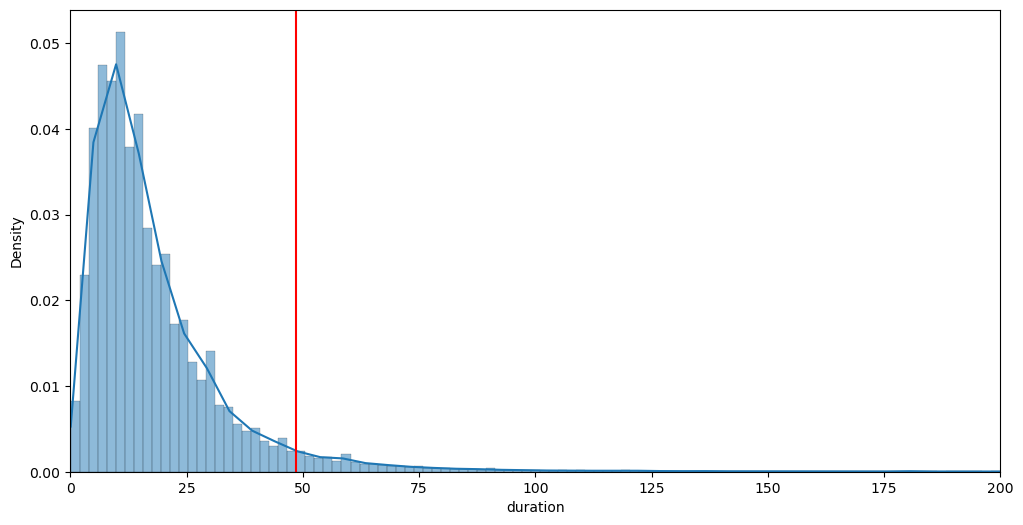

In [26]:
# overall distribution of duration
# there are repetitive peaks, likely since the temporal resolution is discrete with respect ot minutes
fig, ax = plot_density(df["duration"], bins=2000)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

C:\Users\ger225\.conda\envs\gis\lib\site-packages\pandas\core\arraylike.py:358: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'log duration')

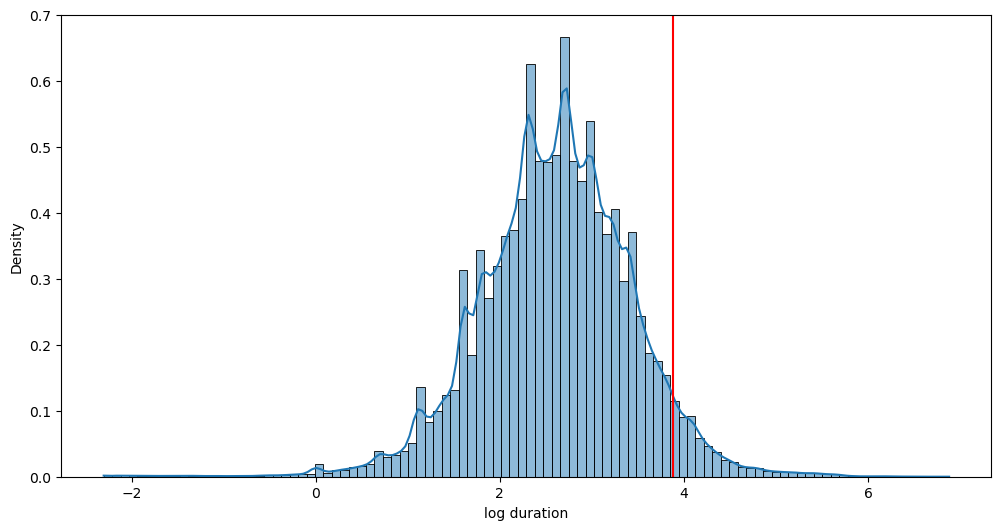

In [27]:
# overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [28]:
## duration analysis segmented by mode

In [29]:
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for mode in valid_modes: # cycle through all modes
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[key]), ax=ax, stat="density", kde=True, label=mode, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[key]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot
    return fig, ax

In [30]:
def show_summaries(df: pd.DataFrame, key: str, percentile=[0.95]): # show normal summaries for each mode side by side
    res = []
    p = [0.25, 0.5, 0.75]
    p = p + percentile
    # p.append(percentile)
    for mode in valid_modes:
        group = df[df["mode"] == mode]
        res.append(group[key].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = valid_modes
    return x

In [201]:
show_summaries(df, "duration")

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,18.542229,23.640117,16.149813,38.154242
std,21.044895,25.802185,18.693085,29.783879
min,0.100000,0.133333,0.100000,0.133333
25%,8.333333,9.000000,6.433333,20.000000
50%,13.816667,16.083333,11.450000,32.033333
75%,22.350000,29.050000,19.466667,48.391667
95%,46.050000,66.286667,42.200000,85.260000
max,970.516667,325.800000,325.466667,570.000000


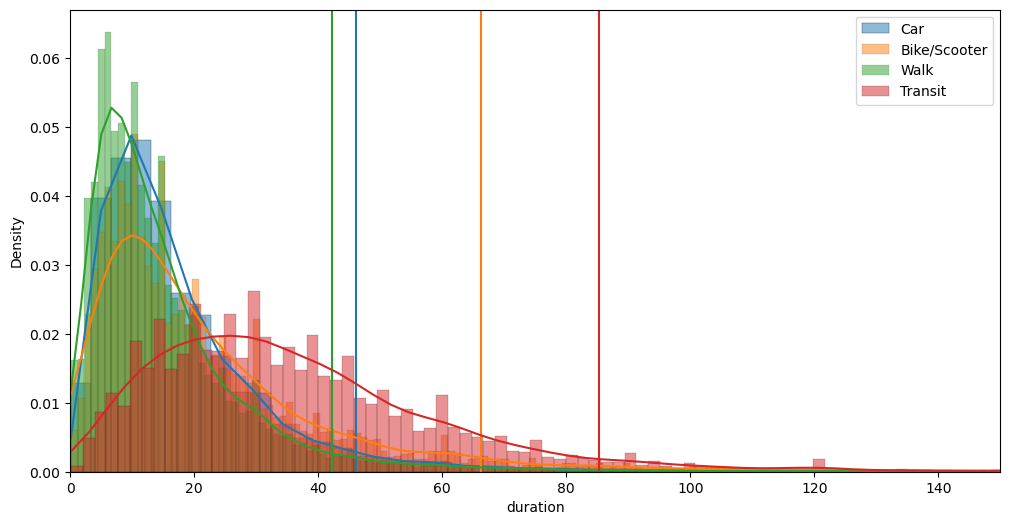

In [32]:
# plot of densities of all modes overlayed on top of one another
fig, ax = plot_mode_density(df, "duration")
ax.set_xlim(left=0, right=150)
plt.legend()

takeaways:

- durations tend to be right-skewed; people prefer shorter durations
- walk durations tend to be the shortest, followed by car, biking, and transit in that order
- there is small bias in durations as it is semi-categorical, with multiple peaks/non-continuous distribution
- the transit duration distribution deviates significantly from the other modes--transit riders are less sensitive to duration
- there remain some duration outliers
- possibly drop duration in favor of distance

potential further analysis:
- trip duration as a percentage of the total tour time

### difference between non-driving trip durations with corresponding driving trip duration

In [202]:
# overall

difference_with_car_duration = df[(df["mode"] != "Car") & (df["mode"].isin(valid_modes))]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] != "Car") & (df["mode"].isin(valid_modes))]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

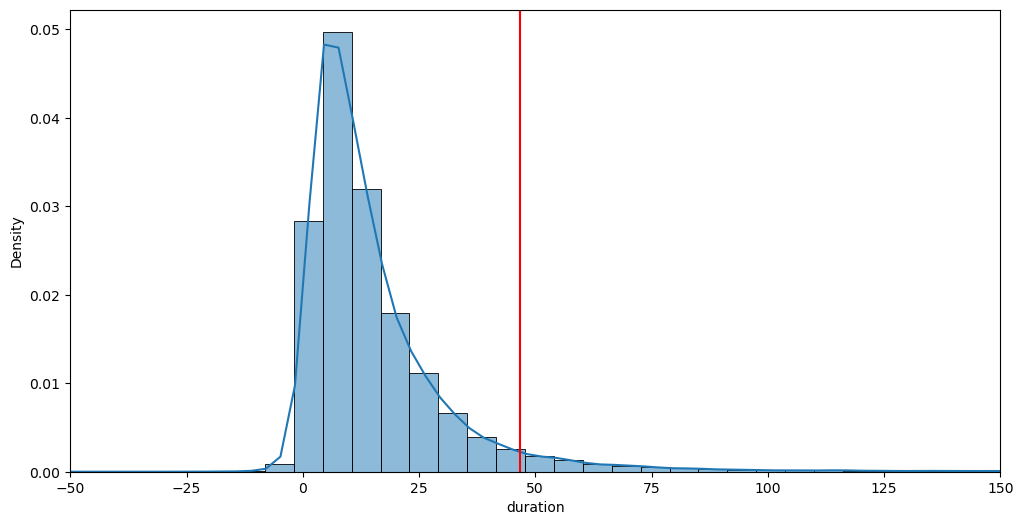

In [203]:
fig, ax = plot_density(difference_with_car_duration)
ax.set_xlim(left=-50, right=150)

In [204]:
difference_with_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    69118.000000
mean        16.152061
std         20.882794
min        -51.665000
25%          5.433333
50%         10.733333
75%         19.591250
95%         46.675250
max        570.000000
Name: duration, dtype: float64

In [205]:
# percent of all non-car trips that are faster than car
(difference_with_car_duration <= 0).sum() / len(difference_with_car_duration)

0.023597326311525217

In [37]:
# bike vs car

In [38]:
# for each bike trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these bikers tradeoff between car & bike duration
bike_minus_car_duration = df[df["mode"] == "Bike/Scooter"]["duration"] - (car.set_index("trip_id").loc[df[(df["mode"] == "Bike/Scooter")]["trip_id"].values].duration_seconds / 60).values

In [39]:
# not sure if it would be feasible to switch to bike if car is 53 minutes faster
# self sampling likely plays a role -- maybe adopt a smaller percentile to adjust?
bike_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    7705.000000
mean       16.805448
std        23.208526
min       -11.326667
25%         5.136667
50%        10.326667
75%        19.445000
95%        53.201667
max       303.550000
Name: duration, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='duration', ylabel='Density'>)

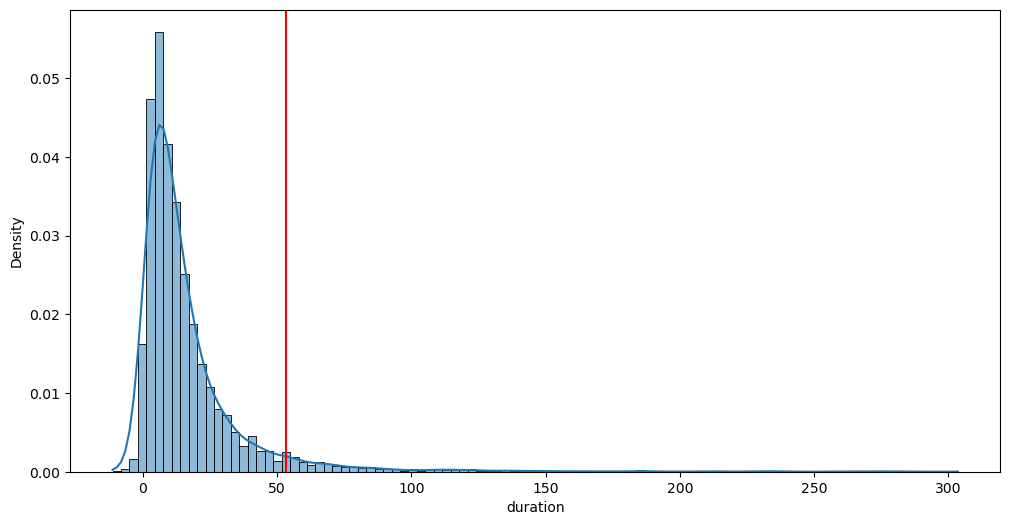

In [40]:
plot_density(bike_minus_car_duration)

In [41]:
# transit vs car

In [42]:
# for each transit trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these transit riders tradeoff between car & transit duration

transit_minus_car_duration = df[df["mode"] == "Transit"]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] == "Transit")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 200.0)

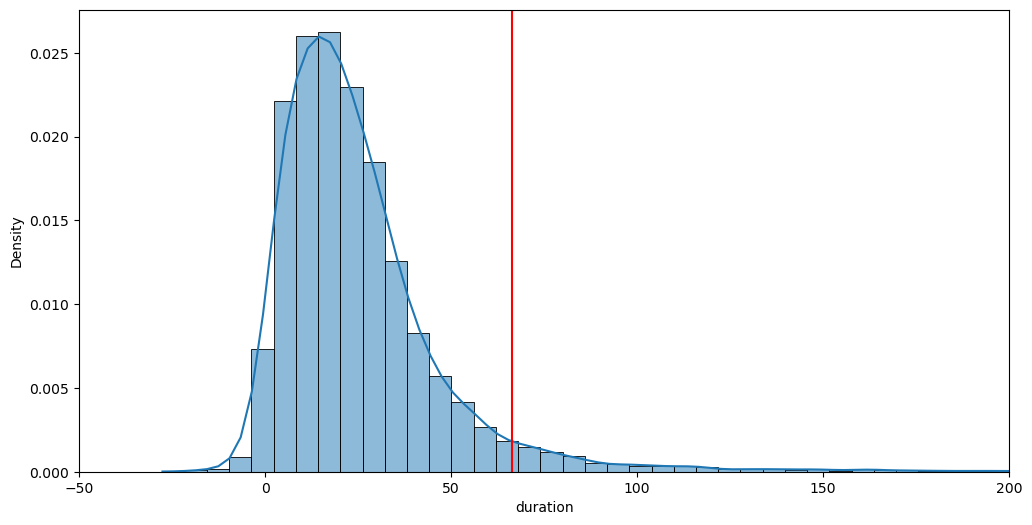

In [43]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(transit_minus_car_duration)
ax.set_xlim(left=-50, right=200)

In [44]:
transit_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11279.000000
mean        25.941877
std         26.901623
min        -27.603333
25%         10.948333
50%         20.401667
75%         32.680000
95%         66.365333
max        570.000000
Name: duration, dtype: float64

In [45]:
# walk vs car

In [46]:
# for each walk trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how walkers tradeoff between car & walk duration

walk_minus_car_duration = df[df["mode"] == "Walk"]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] == "Walk")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

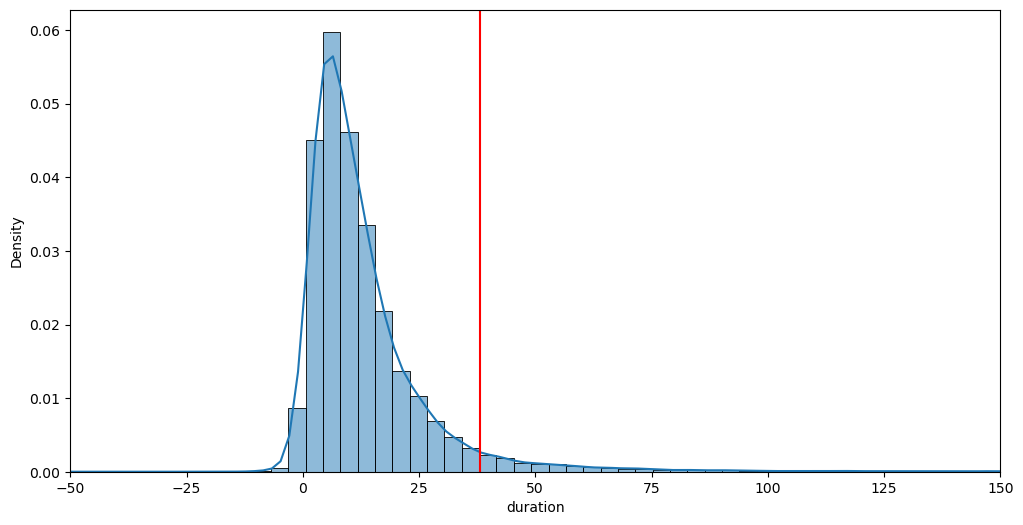

In [47]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(walk_minus_car_duration)
ax.set_xlim(left=-50, right=150)

In [48]:
walk_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    50134.000000
mean        13.849159
std         18.130597
min        -51.665000
25%          5.036667
50%          9.444167
75%         16.567917
95%         38.075750
max        321.598333
Name: duration, dtype: float64

duration difference takeaways

- the distributions for duration difference between mode and car are remarkably similar, with 95 percnetiles around 40-60
- none of these modes can beat out car (and it doesn't even seem close--the amount of trips in each mode where this mode is faster is like 1% for each), so there are some other factors other than duration that drive these people to use these modes
    - this could be due to selection bias -- people who use these modes are "enthusiasts," so a smaller percentile may be needed to account for this

further analysis
- could try a duration percentage analysis as well to standardize duration magnitudes

### difference between driving trip duration with each mode duration

In [49]:
# car trip duration - corresponding bike duration

In [50]:
# for each car trip, find time needed to do it on bike & subtract it from the duration
# - means bike is longer & vice versa
car_duration_minus_bike = df[df["mode"] == "Car"]["duration"] - (bike.set_index("trip_id").loc[df[df["mode"] == "Car"]["trip_id"].values]["duration_seconds"] / 60).values

In [51]:
car_duration_minus_bike.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    377333.000000
mean       -127.969408
std         149.514014
min       -2208.688333
25%        -162.600000
50%         -78.393333
75%         -38.696667
95%          -9.503333
max         849.560000
Name: duration, dtype: float64

(-1000.0, 500.0)

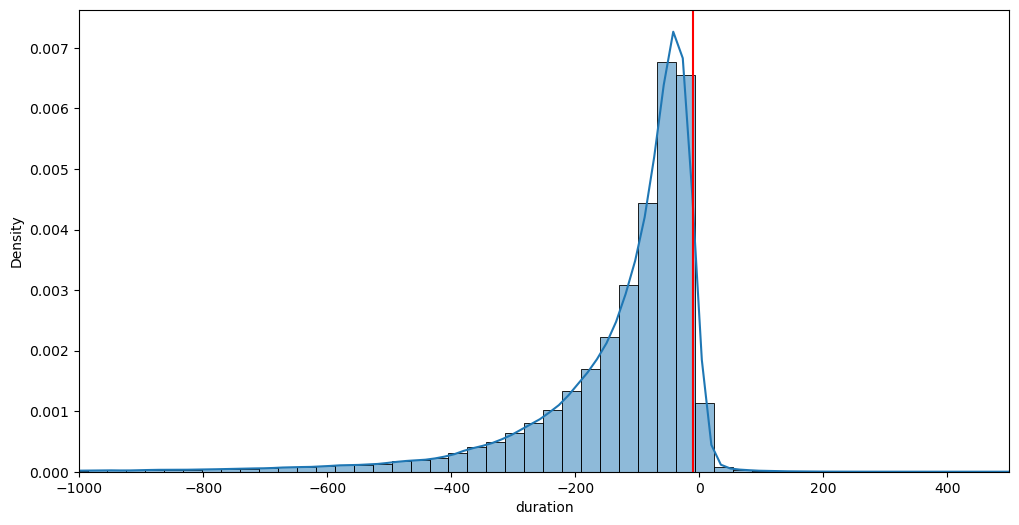

In [52]:
# most car trips are faster than corresponding bike ones but they do seem to cluster around 0 (parity)
fig, ax = plot_density(car_duration_minus_bike)
ax.set_xlim(left=-1000, right=500)

In [53]:
# car trip duration - corresponding walk duration

In [54]:
# for each car trip, find time needed to do it walking & subtract it from the duration
# - means bike is longer & vice versa
car_duration_minus_walk = df[df["mode"] == "Car"]["duration"] - (walk.set_index("trip_id").loc[df[df["mode"] == "Car"]["trip_id"].values]["duration_seconds"] / 60).values

In [55]:
car_duration_minus_walk.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    377333.000000
mean       -113.201516
std         152.765962
min       -2038.931667
25%        -146.701667
50%         -58.693333
75%         -21.730000
95%          -0.970000
max         850.448333
Name: duration, dtype: float64

(-1000.0, 500.0)

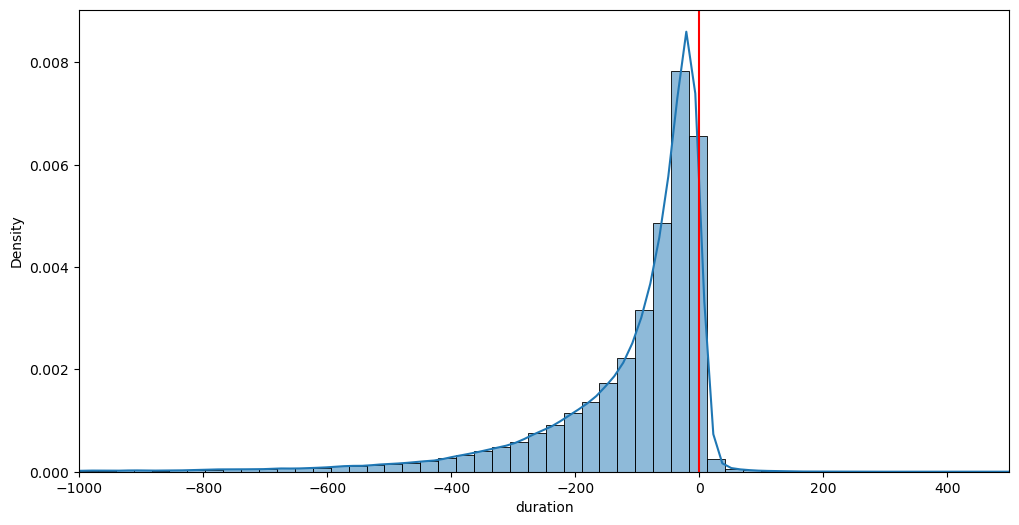

In [56]:
# about the same as bike? but slightly more left-heavy
fig, ax = plot_density(car_duration_minus_walk)
ax.set_xlim(left=-1000, right=500)

In [57]:
# car trip duration - corresponding transit duration

In [58]:
# for each car trip, find time needed to do it via transit & subtract it from the duration (if such a time is found)
# - means bike is longer & vice versa
car_duration_minus_transit = df[(df["mode"] == "Car") & (df["trip_id"].isin(transit_grouped["trip_id"]))]["duration"] - (transit_grouped.loc[df[(df["mode"] == "Car") & (df["trip_id"].isin(transit_grouped["trip_id"]))]["trip_id"].values]["duration"]).values

In [59]:
car_duration_minus_transit.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    142996.000000
mean        -65.526170
std         265.912478
min       -2843.233333
25%         -31.666667
50%         -16.933333
75%          -8.750000
95%           2.466667
max         735.033333
Name: duration, dtype: float64

(-2000.0, 500.0)

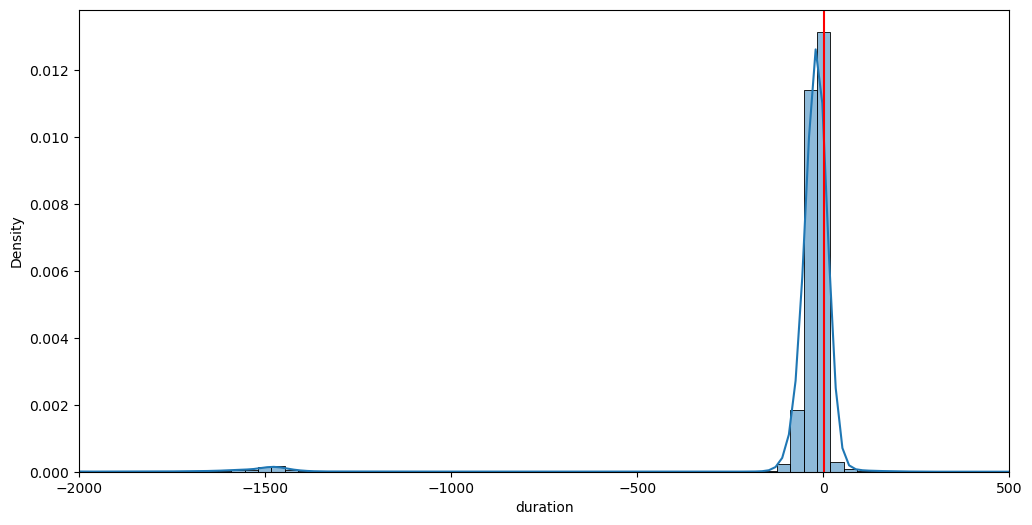

In [60]:
# this is significant different from car/biking; much more clustered around 0 aside from a small cluster near -1500
# have to note that some transit times were left out--could be systemic/due to previous filtering
fig, ax = plot_density(car_duration_minus_transit)
ax.set_xlim(left=-2000, right=500)

In [61]:
# car minus best

In [62]:
# assume no transit trip means missing and 10000 duration
car_duration_minus_transit_cmp = car_duration_minus_transit.reindex(car_duration_minus_bike.index).fillna(10000)

In [63]:
alt_mode_duration_best = pd.concat([car_duration_minus_bike, car_duration_minus_transit_cmp, car_duration_minus_walk], axis=1).apply(min, axis=1)

In [64]:
alt_mode_duration_best.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    377333.000000
mean       -153.011176
std         222.110487
min       -2843.233333
25%        -176.961667
50%         -83.146667
75%         -41.150000
95%         -12.116000
max         849.560000
dtype: float64

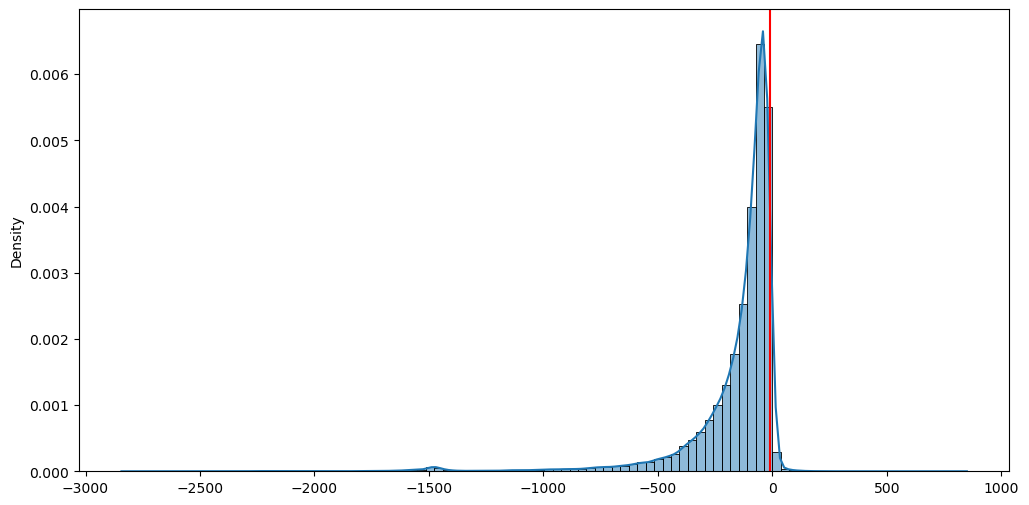

In [65]:
# seems to roughly follow transit distribution
fig, ax = plot_density(alt_mode_duration_best)

difference between driving trip duration with each mode duration takeaways

- for car trips, alternative modes are generally faster
- transit appear to be more close to parity, although there is a small bump at -1500 for some reason
- walk/bike are more varied
- generally mirrors the previous section on difference between mode and driving

### distance analysis

In [66]:
# overall

In [67]:
# summary statistics
df["distance"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean          6.265382
std           8.274941
min           0.010238
25%           1.180789
50%           3.232732
75%           8.103433
95%          22.148011
max          99.978130
Name: distance, dtype: float64

(0.0, 50.0)

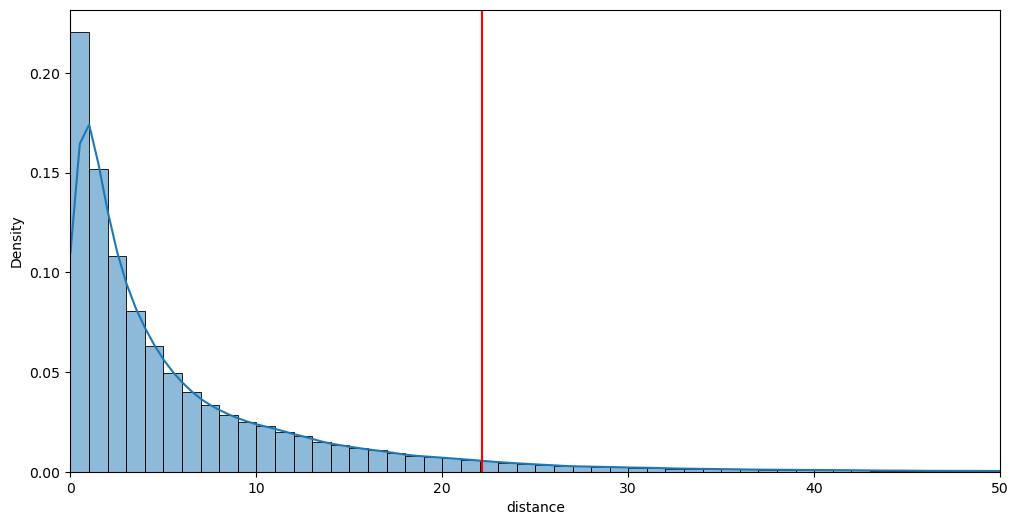

In [68]:
# distribution
fig, ax = plot_density(df["distance"])
ax.set_xlim(left=0, right=50) # max is 99, cut off about half

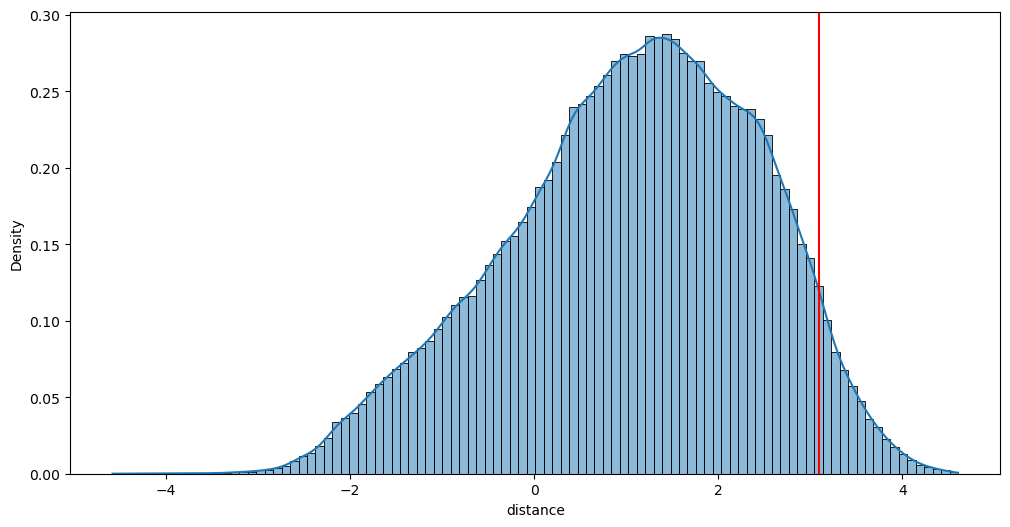

In [69]:
# log distance distribution
# compared with the overall distribution, we see more resolution in the shorter distance trips, which make up a significant portion of all trips
fig, ax = plot_density(np.log(df["distance"]))

In [70]:
# segmented by mode

In [71]:
show_summaries(df, key="distance")

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,7.070595,3.233572,0.698849,6.968255
std,8.618728,4.219710,1.239752,7.469740
min,0.024010,0.057926,0.010238,0.025480
25%,1.678135,0.831384,0.213500,2.151295
50%,3.973360,1.853217,0.397094,4.418200
75%,9.262450,4.052120,0.760542,8.841020
95%,23.540784,10.535152,2.040692,22.071148
max,99.978130,80.358668,67.843162,70.046313


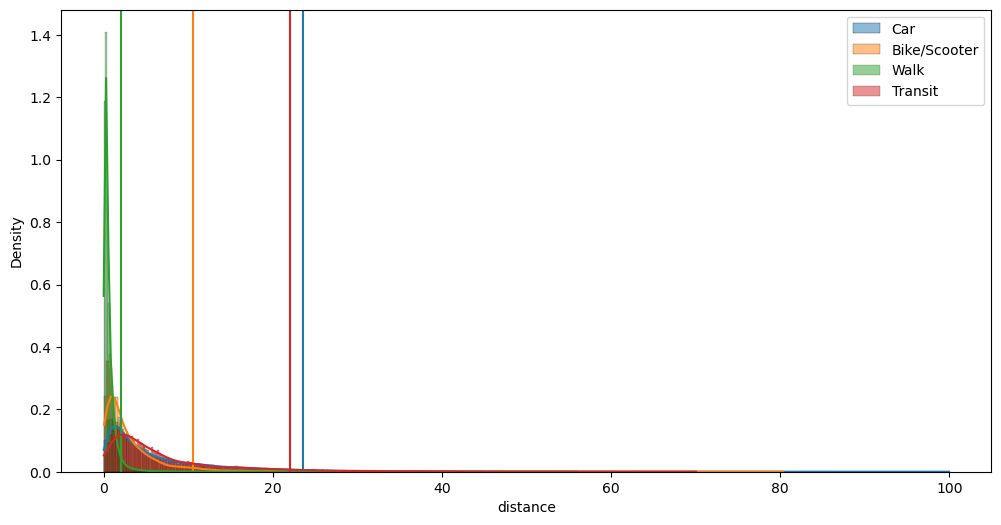

In [72]:
# raw distance distribution (miles)
fig, ax = plot_mode_density(df, key="distance") # walk peak distorts the plot
plt.legend()

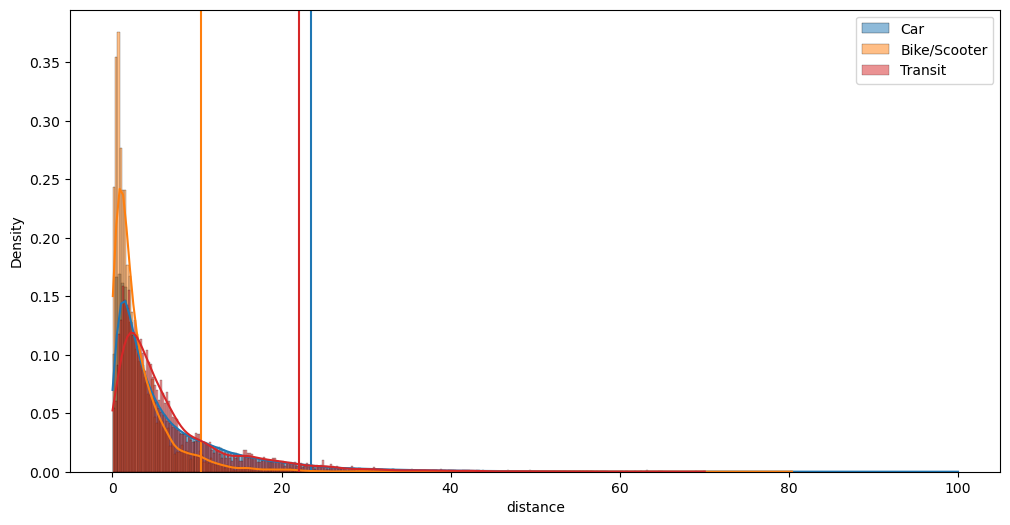

In [73]:
# raw distance distribution (miles) with walk omitted
fig, ax = plot_mode_density(df[df["mode"] != "Walk"], key="distance")
plt.legend()

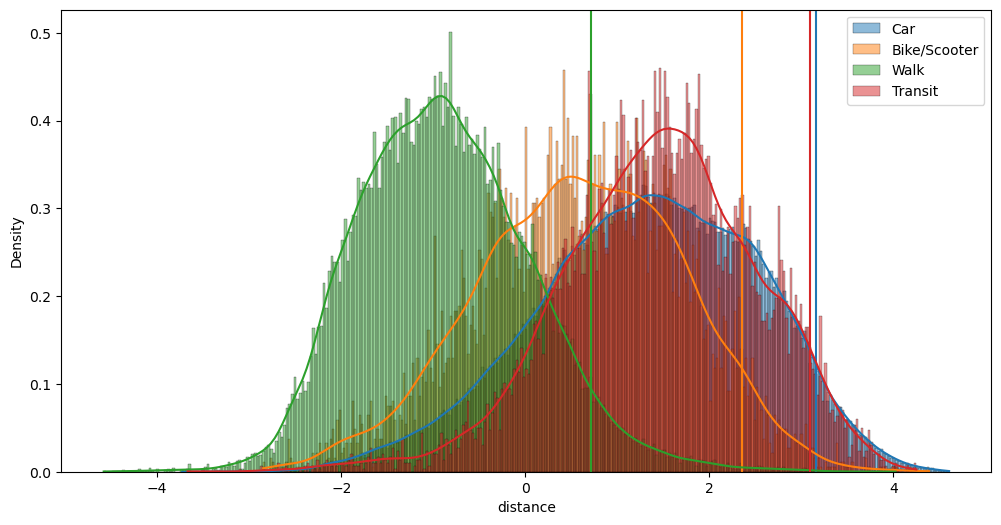

In [74]:
# log distance distribution
fig, ax = plot_mode_density(df, key="distance", function=np.log)
plt.legend()

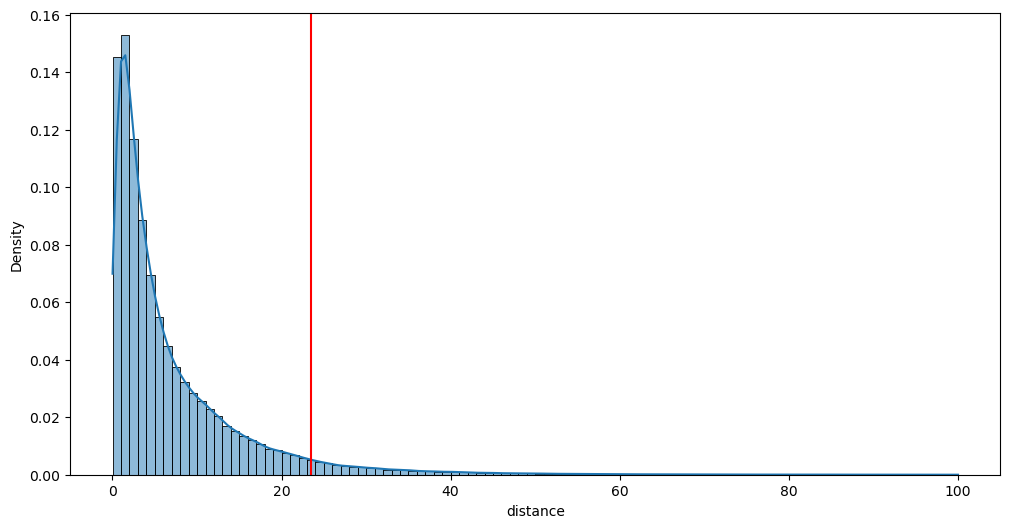

In [75]:
# car distance distribution
fig, ax = plot_density(df[df["mode"] == "Car"]["distance"])

(0.0, 35.0)

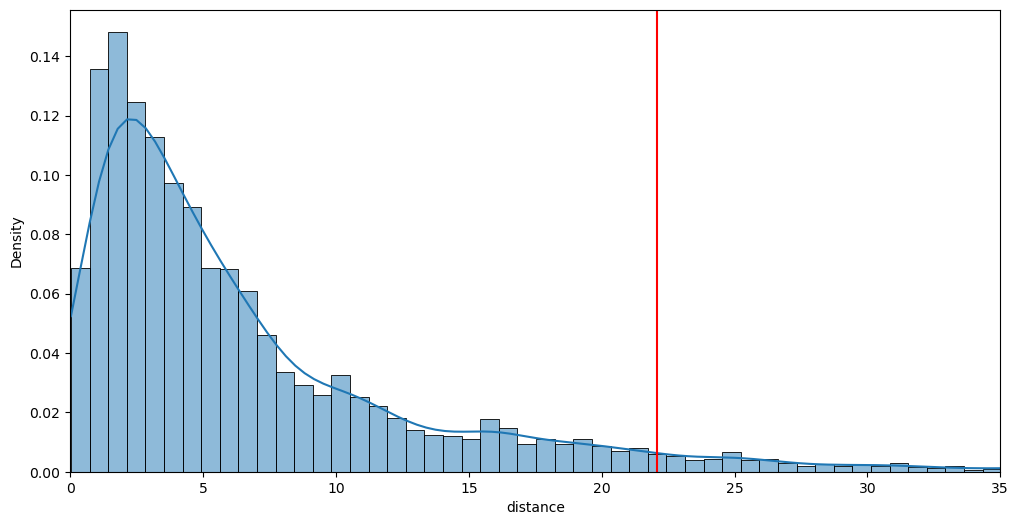

In [76]:
# transit distance distribution
fig, ax = plot_density(df[df["mode"] == "Transit"]["distance"])
ax.set_xlim(left=0, right=35)

(0.0, 4.0)

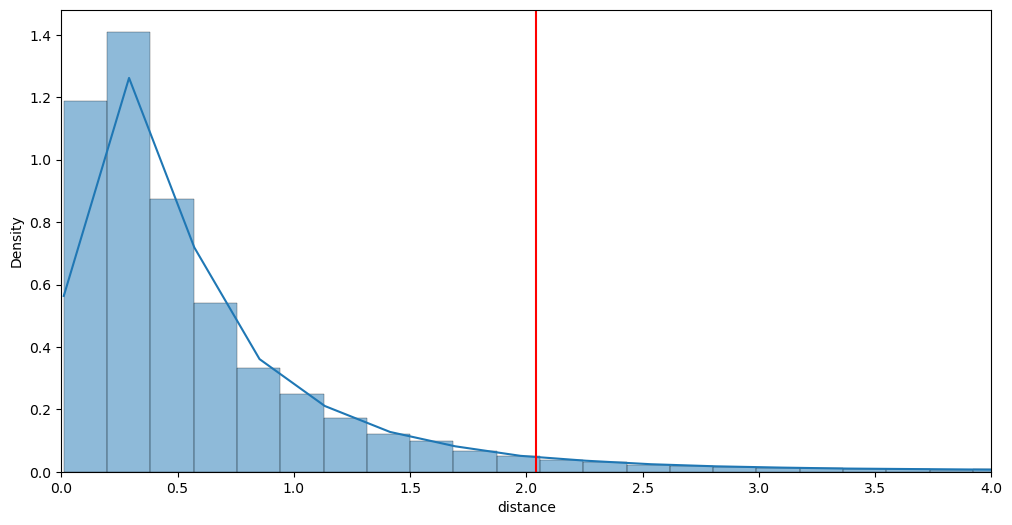

In [77]:
# walk distance distribution
fig, ax = plot_density(df[df["mode"] == "Walk"]["distance"], bins=300)
ax.set_xlim(left=0, right=4)

(0.0, 20.0)

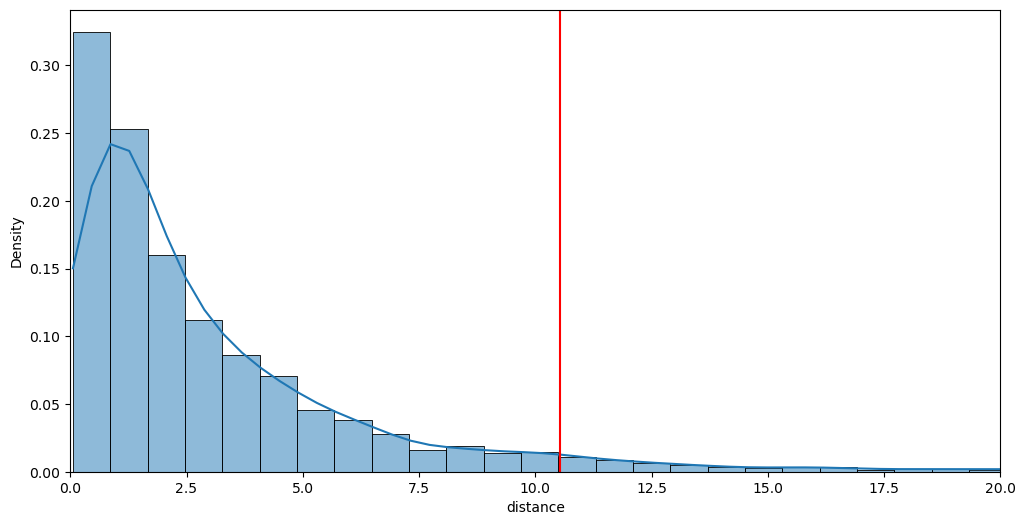

In [78]:
# bike distnace distribution
fig, ax = plot_density(df[df["mode"] == "Bike/Scooter"]["distance"])
ax.set_xlim(left=0, right=20)

distance takeaways

- pretty straight forward, not anything surprising
- more continuous than duration, has a continuous decline from 0 distance trips, very much right skewed
    - people prefer shorter distance trips
- car and transit distance distributions are relatively similar -- transit & car riders have relatively similar sensitivies to distance
- walk trips are generally about 1 mile or less
- bike/scooter trips are a middle ground between car/transit and walk

further analysis
- we could do a distance vs car analysis but this probably wouldn't show much--difference between walking around a square and cutting through the middle
- maybe distance in certain areas? like cbd vs suburban or something
    - already done with lts + los


### season / temperature

In [79]:
df["month"] = df["travel_date"].str[5:7]

In [80]:
def map_to_season(month):
    # can change to a more granular definition
    match month:
        case '12' | '01' | '02':
            return "winter"
        case '03' | '04' | '05':
            return "spring"
        case '06' | '07' | '08':
            return "summer"
        case _:
            return "autumn"

SyntaxError: invalid syntax (<ipython-input-78-b23331562249>, line 3)

In [81]:
df["season"] = df["month"].apply(map_to_season)
df["season"] = df["month"].apply(map_to_season)

NameError: name 'map_to_season' is not defined

<Axes: xlabel='season', ylabel='count'>

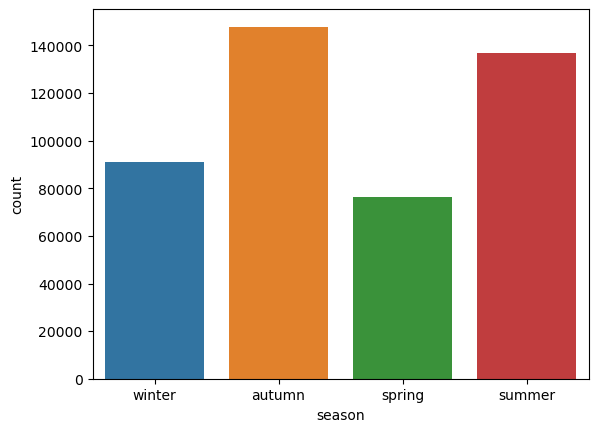

In [82]:
# distribution of season
# WARNING: this could be biased due to the timespan of the data collection -- some season may have been cut short
sns.countplot(x="season", data=df)

In [83]:
# season distribution by mode

In [84]:
# mode share
def plot_mode_barplot_pct_total(df: pd.DataFrame, key: str, mode:str, func=lambda x: x, figsize=(7, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=df[key].value_counts().sort_index().index, y=func(df[df["mode"] == mode][key].value_counts().sort_index()), ax=ax)
    return fig, ax

In [420]:
def plot_stacked_mode_share(x):
    fig, ax = plt.subplots()
    vals = df[x].value_counts().sort_index().index
    temp = pd.DataFrame(index=["Car", "Transit", "Bike/Scooter", "Walk"], columns=vals, data=0)
    temp.loc["Car"] = df[df["mode"] == "Car"][x].value_counts().sort_index() / df[x].value_counts()
    temp.loc["Walk"] = df[df["mode"] == "Walk"][x].value_counts().sort_index() / df[x].value_counts()
    temp.loc["Transit"] = df[df["mode"] == "Transit"][x].value_counts().sort_index() / df[x].value_counts()
    temp.loc["Bike/Scooter"] = df[df["mode"] == "Bike/Scooter"][x].value_counts().sort_index() / df[x].value_counts()
    print(temp)
    print(df[df["mode"] == "Car"][x].value_counts() / df[x].value_counts())
    temp.T.plot(kind="bar", stacked=True, ax=ax)
    return fig, ax

                autumn    spring    summer    winter
Car           0.830061  0.848928  0.809257  0.869275
Transit       0.025604  0.025735  0.021062  0.029092
Bike/Scooter  0.016779  0.013666  0.028348  0.003351
Walk          0.113042  0.096958  0.136797  0.080342
autumn    0.830061
summer    0.809257
winter    0.869275
spring    0.848928
Name: season, dtype: float64


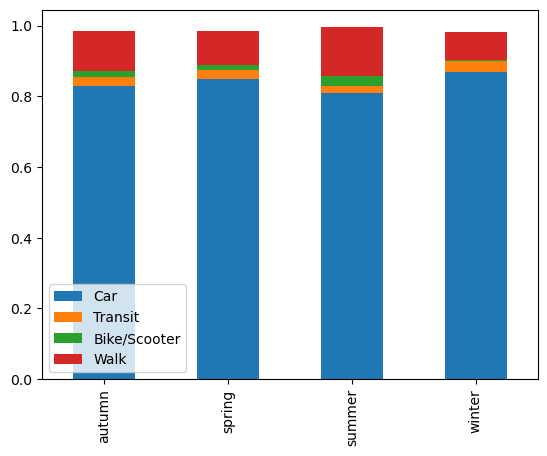

In [421]:
# overall mode shares in stacked format to allow for easy reading
fig, ax = plot_stacked_mode_share("season")

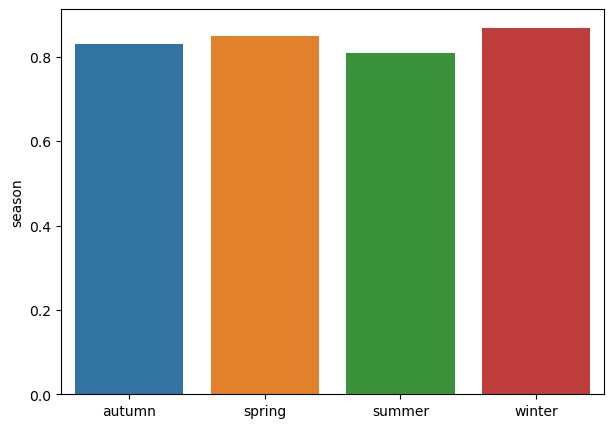

In [85]:
# car seasons
# little variation in car trip % between seasons aside from a slight dip in the summer and slight bump in winter
# thsi represents the % of trips in each season that were by car
fig, ax = plot_mode_barplot_pct_total(df, "season", "Car", lambda x: x / df["season"].value_counts())

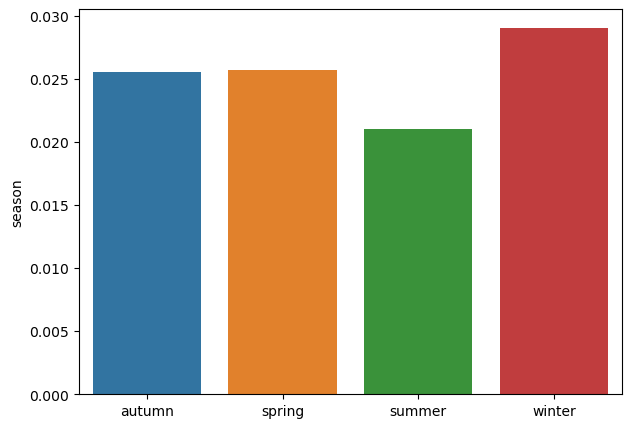

In [86]:
# transit seasons
# significant summer dip & somewhat significant winter bump (possibly due to unsafe conditions otherwise?)
fig, ax = plot_mode_barplot_pct_total(df, "season", "Transit", lambda x: x / df["season"].value_counts())

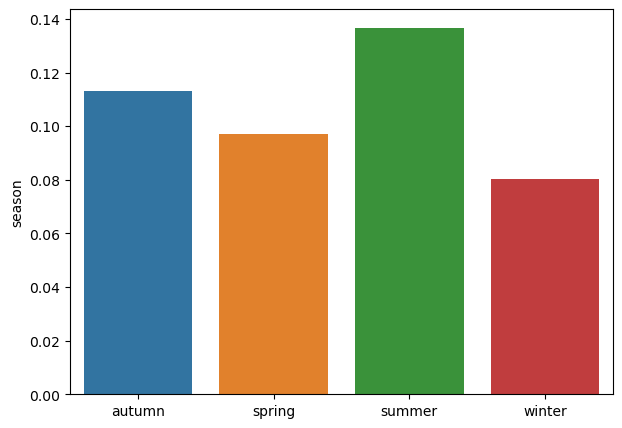

In [87]:
# walk seasons
# significant summer bump & significant winter dip
fig, ax = plot_mode_barplot_pct_total(df, "season", "Walk", lambda x: x / df["season"].value_counts())

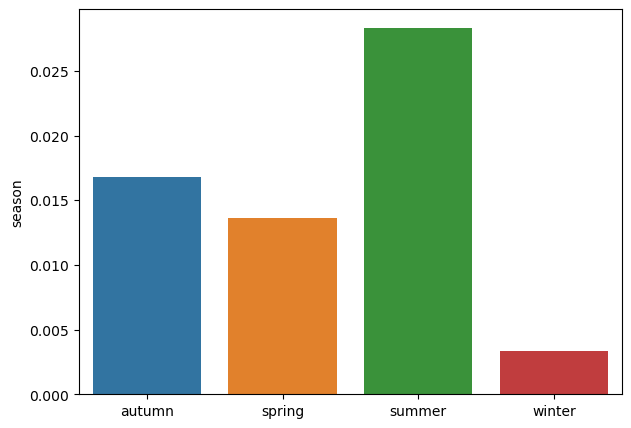

In [88]:
# bike season
# very significant summer bump & very significant winter dip
# basically walk but more extreme variation
fig, ax = plot_mode_barplot_pct_total(df, "season", "Bike/Scooter", lambda x: x / df["season"].value_counts())

In [89]:
# segmentation by month

<Axes: xlabel='month', ylabel='count'>

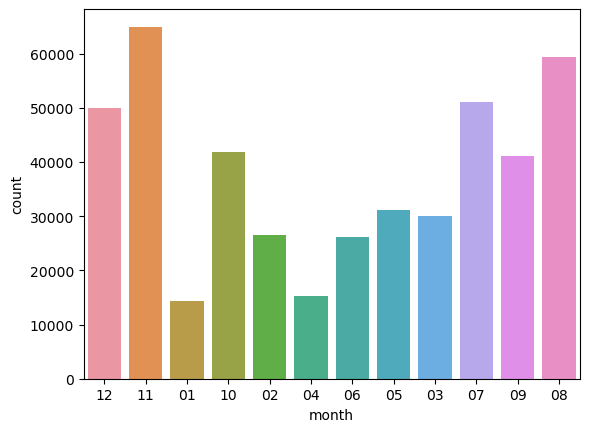

In [90]:
# distribution of month
# WARNING: this could be biased due to the timespan of the data collection -- some season may have been cut short
sns.countplot(x="month", data=df)

                    01        02        03        04        05        06  \
Car           0.882337  0.893846  0.869864  0.855575  0.825439  0.825767   
Transit       0.025669  0.026745  0.023828  0.029068  0.025935  0.019245   
Bike/Scooter  0.003191  0.000828  0.006498  0.013587  0.020626  0.027912   
Walk          0.069446  0.059171  0.084080  0.089033  0.113296  0.121501   

                    07        08        09        10        11        12  
Car           0.803387  0.807030  0.802634  0.823122  0.851874  0.852454  
Transit       0.015705  0.026477  0.032306  0.022591  0.023307  0.031324  
Bike/Scooter  0.029649  0.027420  0.024783  0.016136  0.012131  0.004738  
Walk          0.146213  0.135434  0.128104  0.120102  0.098972  0.094733  
01    0.882337
02    0.893846
03    0.869864
04    0.855575
05    0.825439
06    0.825767
07    0.803387
08    0.807030
09    0.802634
10    0.823122
11    0.851874
12    0.852454
Name: month, dtype: float64


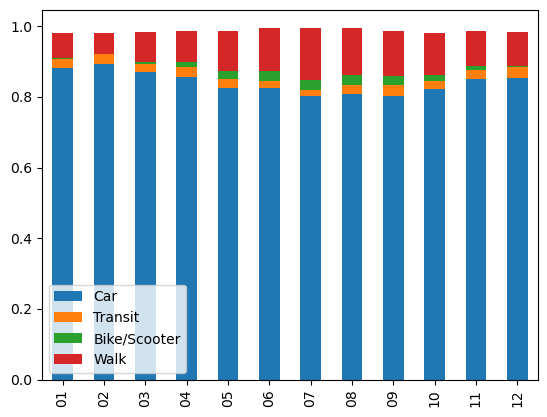

In [422]:
# ovearll mode share in terms of month in stacked format
fig, ax = plot_stacked_mode_share("month")

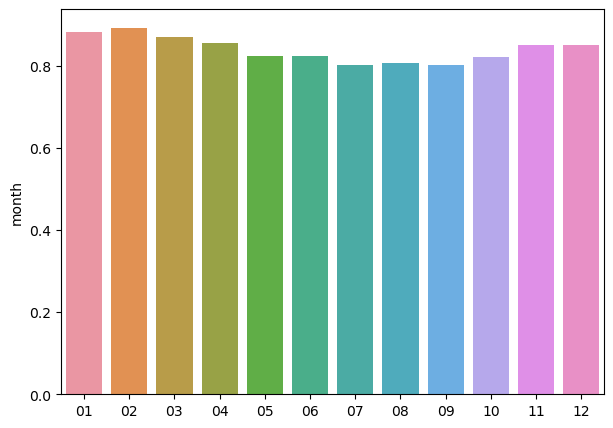

In [91]:
# car months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Car", lambda x: x / df["month"].value_counts())

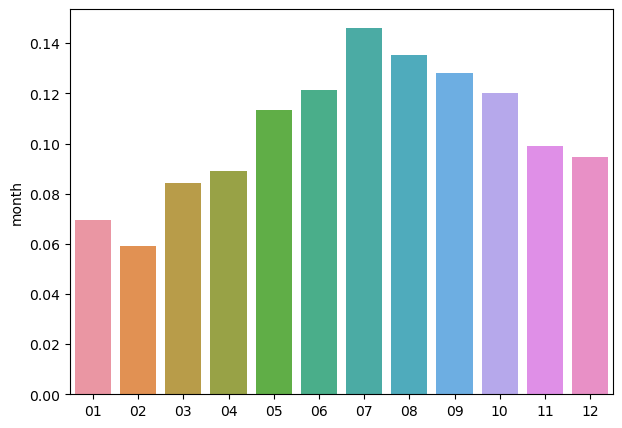

In [92]:
# walk months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Walk", lambda x: x / df["month"].value_counts())

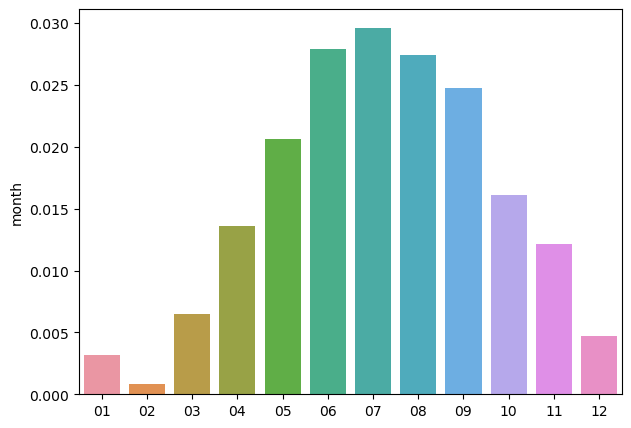

In [93]:
# bike months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Bike/Scooter", lambda x: x / df["month"].value_counts())

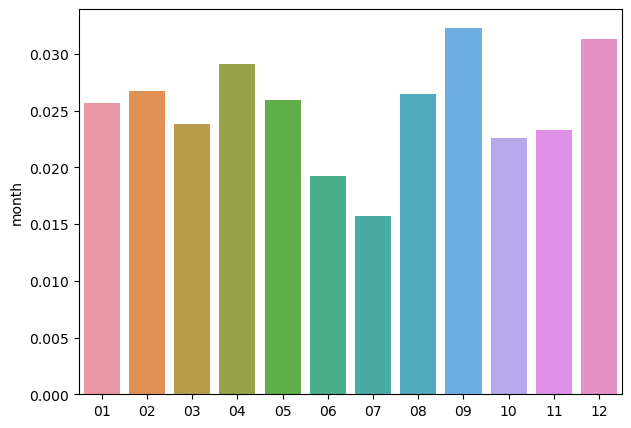

In [94]:
# transit months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Transit", lambda x: x / df["month"].value_counts())

In [95]:
# temperature/precipitation/snowfall

In [97]:
# https://www.ncei.noaa.gov/pub/data/ghcn/daily/
weather = pd.read_csv(data_dir + "/Data_Processed/extra_data/USW00014922.csv")
weather = weather[["Date", "Measurement", "Value"]]
weather = weather.pivot(index="Date", columns="Measurement", values="Value")
weather

C:\Users\yianz\AppData\Local\Temp\ipykernel_19512\3479397492.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv(data_dir + "/Data_Processed/extra_data/USW00014922.csv")


Measurement,ACMH,ACSH,ADPT,ASLP,ASTP,AWBT,AWND,FMTM,FRGT,PGTM,...,WT16,WT17,WT18,WT19,WT21,WT22,WV01,WV03,WV07,WV20
Date,,,,,,,,,,,,,,,,,,,,,
19380409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20230311,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20230312,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20230313,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
weather["year"] = weather.index.astype(str).str[0:4]
weather["month"] = weather.index.astype(str).str[4:6]
weather["day"] = weather.index.astype(str).str[6:8]
weather["date"] = weather["year"] + "-" + weather["month"] + "-" + weather["day"]
weather = weather.set_index("date")
weather

Measurement,ACMH,ACSH,ADPT,ASLP,ASTP,AWBT,AWND,FMTM,FRGT,PGTM,...,WT19,WT21,WT22,WV01,WV03,WV07,WV20,year,month,day
date,,,,,,,,,,,,,,,,,,,,,
1938-04-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,09
1938-04-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,10
1938-04-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,11
1938-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,12
1938-04-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1938,04,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-11,NaN,NaN,NaN,NaN,NaN,NaN,57.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,11
2023-03-12,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,12
2023-03-13,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,03,13


In [99]:
# see https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt for a key
df["temperature"] = (weather.loc[df["travel_date"].values, "TAVG"] / 10).values # average temperature in Celsius
df["precipitation"] = (weather.loc[df["travel_date"].values, "PRCP"] / 10).values # precipition in mm
df["snowfall"] = (weather.loc[df["travel_date"].values, "SNOW"] / 10).values # snowfall in mm

In [100]:
df["temperature_max"] = (weather.loc[df["travel_date"].values, "TMAX"] / 10).values # average temperature in Celsius
df["temperature_min"] = (weather.loc[df["travel_date"].values, "TMIN"] / 10).values # average temperature in Celsius
df["precipitation"] = (weather.loc[df["travel_date"].values, "PRCP"] / 10).values # precipition in mm
df["snow_depth"] = (weather.loc[df["travel_date"].values, "SNWD"] / 10).values # snowfall in mm

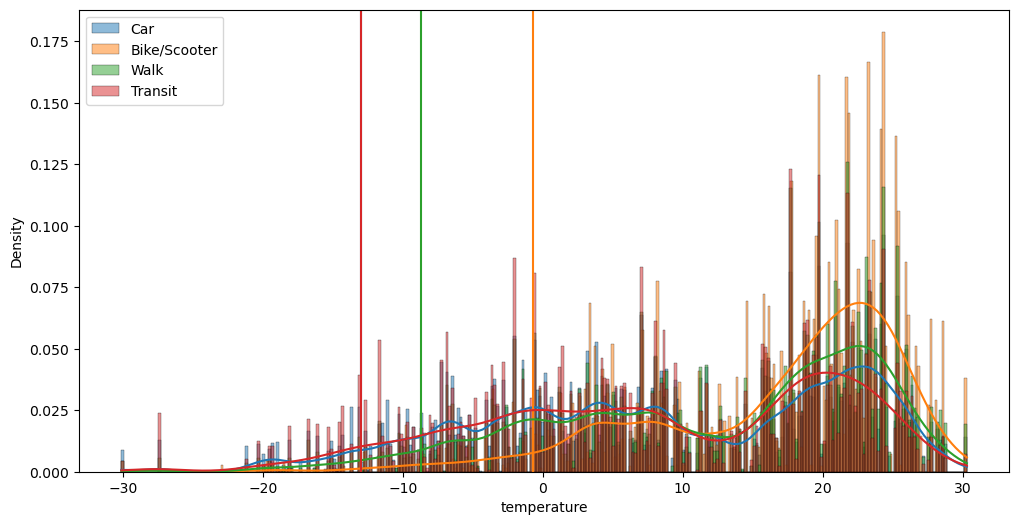

In [101]:
# distribution of average temperature on travel day for each mode
fig, ax = plot_mode_density(df, "temperature", percentile=0.05)
plt.legend()

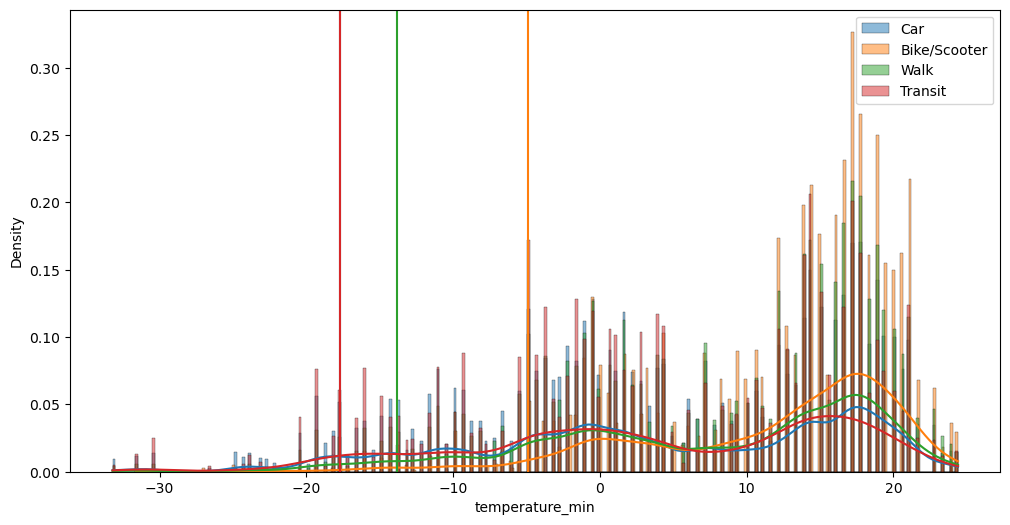

In [102]:
# distribution of average temperature on travel day for each mode
fig, ax = plot_mode_density(df, "temperature_min", percentile=0.05)
plt.legend()

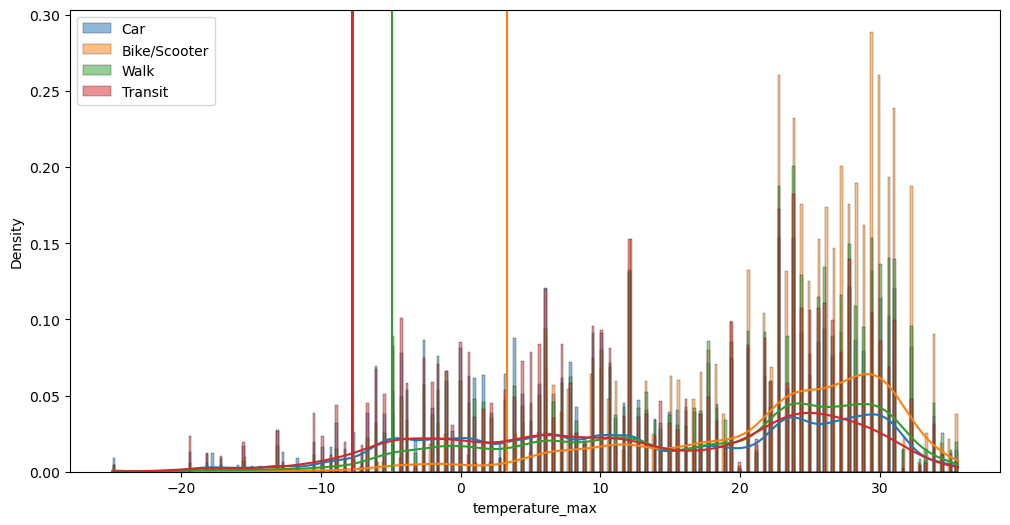

In [103]:
# distribution of average temperature on travel day for each mode
fig, ax = plot_mode_density(df, "temperature_max", percentile=0.05)
plt.legend()

In [104]:
show_summaries(df, "temperature")

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,8.888015,16.701908,12.094738,8.447025
std,12.825022,9.139786,11.627307,12.584399
min,-30.100000,-23.000000,-30.100000,-30.100000
25%,-0.800000,11.200000,3.200000,-1.200000
50%,8.800000,19.700000,16.000000,8.500000
75%,20.900000,23.300000,21.800000,19.700000
95%,25.900000,26.800000,26.100000,25.400000
max,30.300000,30.300000,30.300000,30.300000


(0.0, 15.0)

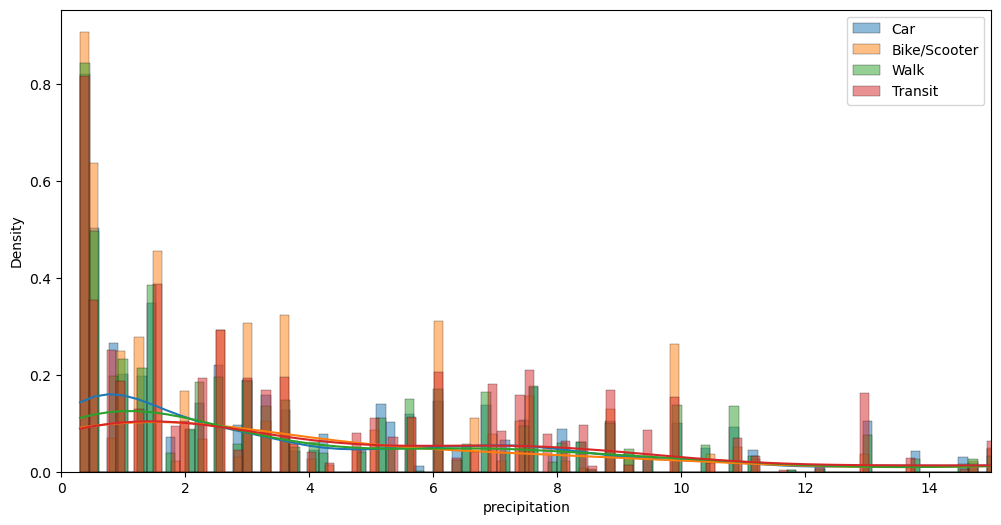

In [105]:
# distribution of precipitation on travel day for each mode
# not very meaningful as most days didn't have precipitation
# the 95th percentiles overlap
fig, ax = plot_mode_density(df[df["precipitation"] != 0], "precipitation")
plt.legend()
ax.set_xlim(left=0, right=15)

In [210]:
# can see a bit more with summary statistics (mean)
# lower percentiles reach 0 rainfall
show_summaries(df, "precipitation", percentile=[0.8, 0.85, 0.9, 0.95])

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,2.148609,1.620973,1.993948,2.221784
std,5.783071,5.239221,5.648606,5.629256
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.800000,0.000000,0.300000,1.000000
80%,2.000000,0.500000,1.300000,2.500000
85%,3.800000,1.500000,3.000000,5.100000
90%,7.400000,4.100000,6.900000,7.600000


(0.0, 15.0)

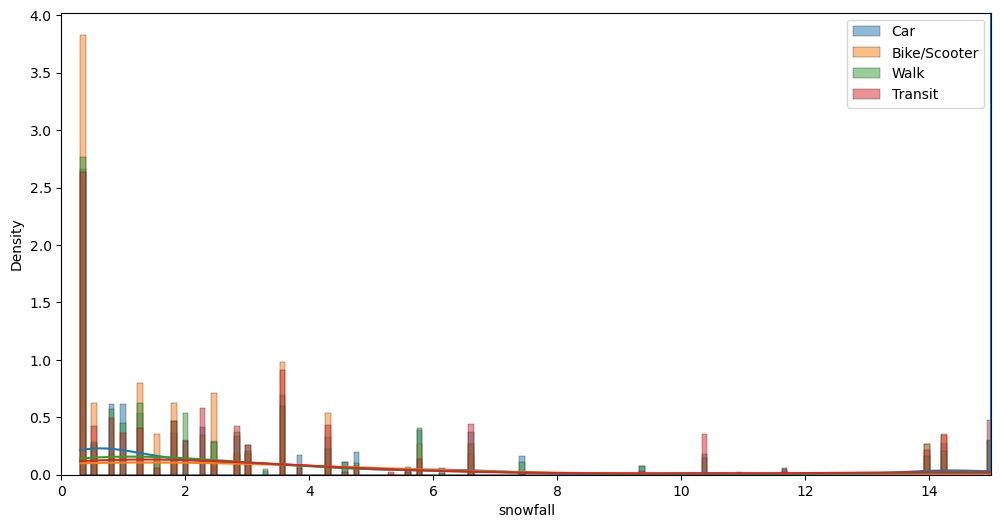

In [112]:
# distribution of snowfall on travel day for each mode
# not very meaningful as most days didn't have snowfall
fig, ax = plot_mode_density(df[df["snowfall"] != 0], "snowfall")
plt.legend()
ax.set_xlim(left=0, right=15)

In [211]:
# can see a bit more with summary statistics (mean)
# notably, 95% of bike trips occur when there is no snow
show_summaries(df, "snowfall", percentile=[0.8, 0.85, 0.9, 0.95])

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,0.422939,0.068241,0.327803,0.578908
std,2.213814,1.077439,2.246391,2.879666
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
80%,0.000000,0.000000,0.000000,0.000000
85%,0.000000,0.000000,0.000000,0.000000
90%,0.300000,0.000000,0.000000,0.300000


In [212]:
show_summaries(df, "snow_depth", percentile=[0.8, 0.85, 0.9, 0.95])

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,4.584362,0.535626,2.681833,4.549073
std,11.002024,3.575990,8.148748,10.489985
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000,3.000000
80%,5.000000,0.000000,0.000000,8.000000
85%,10.000000,0.000000,3.000000,10.000000
90%,13.000000,0.000000,10.000000,13.000000


takeaways

- seasons do seem to play a large part in the relative proportions of mode trips for non-driving modes
    - comparing relative proportions in distance should be able to handle the sampling timing bias
    - this effect is very pronounced for walking and biking
    - this effect is seen more granularly with month segmentation
- temperature, precipitation, and snowfall also have effects and get more at the causes between month/seaseon trends
    - temperature is the most meaningful; bike trips don't happen in snow 95% of the time

future analysis
- how do we apply a 95% rule for categorical variables? -- probably need an alternative feasibility indicator
    - could just cut out extreme dips -- e.g., people don't bike in winter

### daylight hours indicator & departure time

In [116]:
def plot_multi_barplot(df: pd.DataFrame, x: str, y: str, figsize=(7, 5), order=None):
    # plot normalized bar plot of the values in each mode side by side
    fig, ax = plt.subplots(figsize=figsize)
    if y == "mode": 
        df = df[df["mode"].isin(valid_modes)]
    (df
     .groupby(y)[x]
     .value_counts(normalize=True)
     .mul(100)
     .rename("percent")
     .reset_index()
     .pipe((sns.barplot, "data"), x=x, y="percent", hue=y, ax=ax, order=order)
    )
    
    return fig, ax

In [117]:
df["datetime"] = df["travel_date"].apply(lambda x: dt.strptime(x, r"%Y-%m-%d"))
df["datetime"] = df["datetime"].astype('M8[D]').astype('O') # somehow converts datetime64[ns] into datetime

In [118]:
central = pytz.timezone("US/Central")
df[["sunrise", "sunset"]] = pd.DataFrame(get_times(df['datetime'], df["o_lon"], df["o_lat"]))[["sunrise", "sunset"]].applymap(lambda x: x.astimezone(central)) # parsed as utc, convert to central

c:\Users\yianz\miniconda3\envs\vmtmodeenv\lib\site-packages\suncalc\suncalc.py:84: FutureWarning: The behavior of .astype from datetime64[ns] to int32 is deprecated. In a future version, this astype will return exactly the specified dtype instead of int64, and will raise if that conversion overflows.
  return np.array(pd.to_datetime(date).astype(int) / 10 ** 6)


In [119]:
# get standardized sunrise_time/sunset_time to allow for direct string comparison 
df["sunrise_time"] = df["sunrise"].dt.hour.astype(str).str.zfill(2) + ":" + df["sunrise"].dt.minute.astype(str).str.zfill(2) + ":" + df["sunrise"].dt.second.astype(str).str.zfill(2)
df["sunset_time"] = df["sunset"].dt.hour.astype(str).str.zfill(2) + ":" + df["sunset"].dt.minute.astype(str).str.zfill(2) + ":" + df["sunset"].dt.second.astype(str).str.zfill(2)

In [120]:
# string comparison works since 13 > 03--alphabetical is chronological
df["during_daylight"] = (df["depart_time"] > df["sunrise_time"]) & (df["arrive_time"] < df["sunset_time"])

<Axes: xlabel='during_daylight', ylabel='count'>

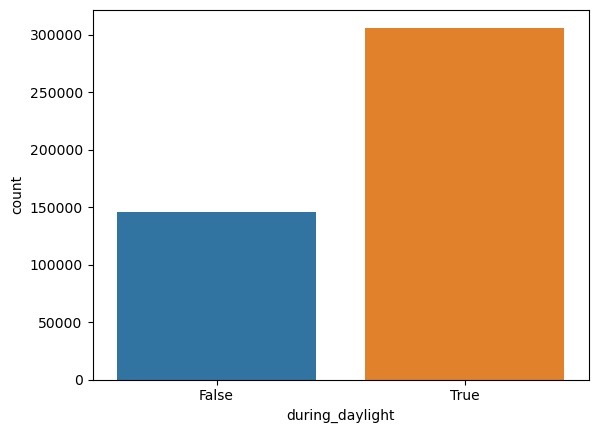

In [121]:
# distribution of trips w.r.t occurring wthin daylight hours
# majority are within daylight hours
# this doesn't have the problem as with seasons as daylight occurs on a daily basis, which the survye likely captures
sns.countplot(x="during_daylight", data=df)

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='during_daylight', ylabel='percent'>)

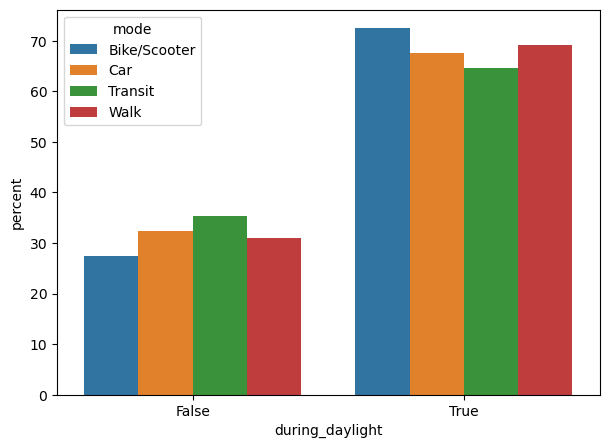

In [122]:
# bar plot of the % of trips in a given mode that occur during/not during daylight side by side for all modes
# less relative walk/transit trips at night/more at day
# more relative transit/car trips at night, more at day
plot_multi_barplot(df, "during_daylight", "mode")

In [123]:
# departure time analysis -- similar to during_daylight but more continuous

In [124]:
df["depart_time_dt"] = df["depart_time"].apply(lambda x: dt.strptime(x, "%H:%M:%S"))
df["depart_time_dt"]

0        1900-01-01 12:30:00
1        1900-01-01 22:00:00
2        1900-01-01 05:45:00
3        1900-01-01 14:00:00
4        1900-01-01 10:45:00
                 ...        
451969   1900-01-01 23:13:00
451970   1900-01-01 14:06:00
451971   1900-01-01 23:03:00
451972   1900-01-01 13:50:00
451973   1900-01-01 23:00:00
Name: depart_time_dt, Length: 451974, dtype: datetime64[ns]

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='depart_time_dt', ylabel='Density'>)

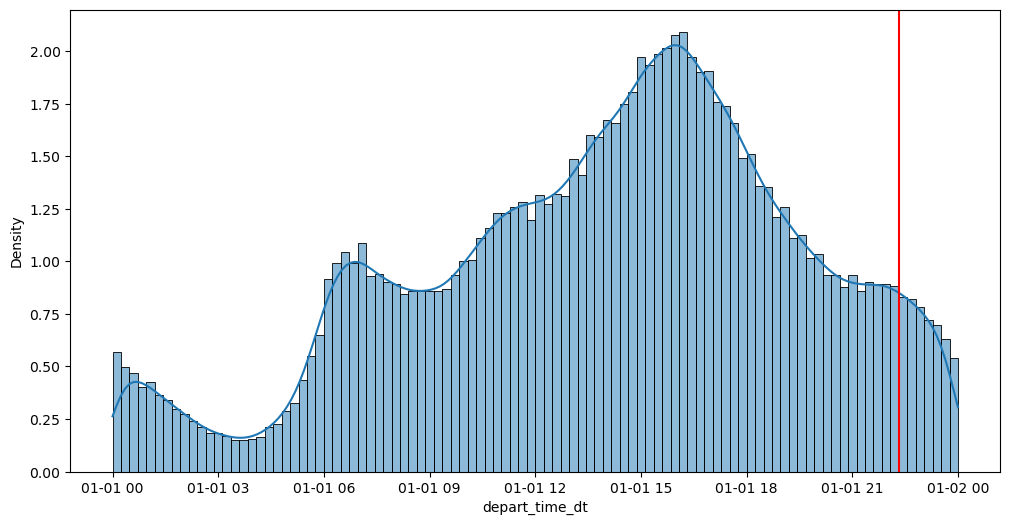

In [125]:
# everything is in 1900 but that doesn't matter -- only look at hours
# need an alternative feasibility indicator other than 95% -- possibly both extremes, 2 tailed?
# most trips occur during daytime
plot_density(df["depart_time_dt"])

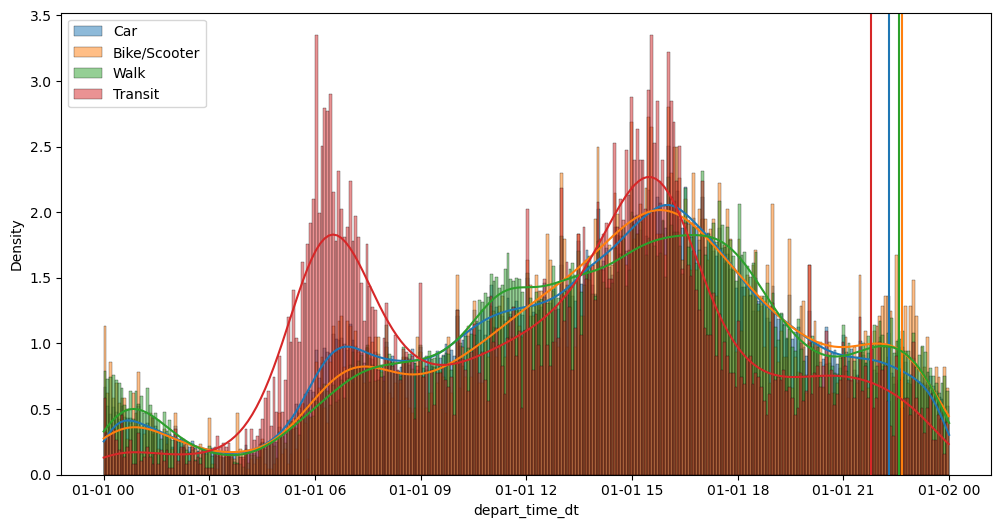

In [126]:
# departure time segmented by mode
# not very meaningful, likely due to daytime differences
fig, ax = plot_mode_density(df, key="depart_time_dt")
plt.legend()

In [128]:
def get_time_from_daylight(row):
    if row["during_daylight"]:
        return 0
    curr_time = row["depart_time_dt"].hour * 60 * 60 + row["depart_time_dt"].minute * 60 + row["depart_time_dt"].second
    sunrise = row["sunrise"].hour * 60 * 60 + row["sunrise"].minute * 60 + row["sunrise"].second
    sunset = row["sunset"].hour * 60 * 60 + row["sunset"].minute * 60 + row["sunset"].second
    return min(abs(curr_time - sunrise), abs(curr_time - sunset))

In [129]:
df["time_from_daylight"] = df.apply(lambda x: get_time_from_daylight(x), axis=1) # seconds away from daylight hours

In [130]:
df["time_from_daylight"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean       2947.306770
std        6022.360814
min           0.000000
25%           0.000000
50%           0.000000
75%        2423.000000
95%       18602.000000
max       28638.000000
Name: time_from_daylight, dtype: float64

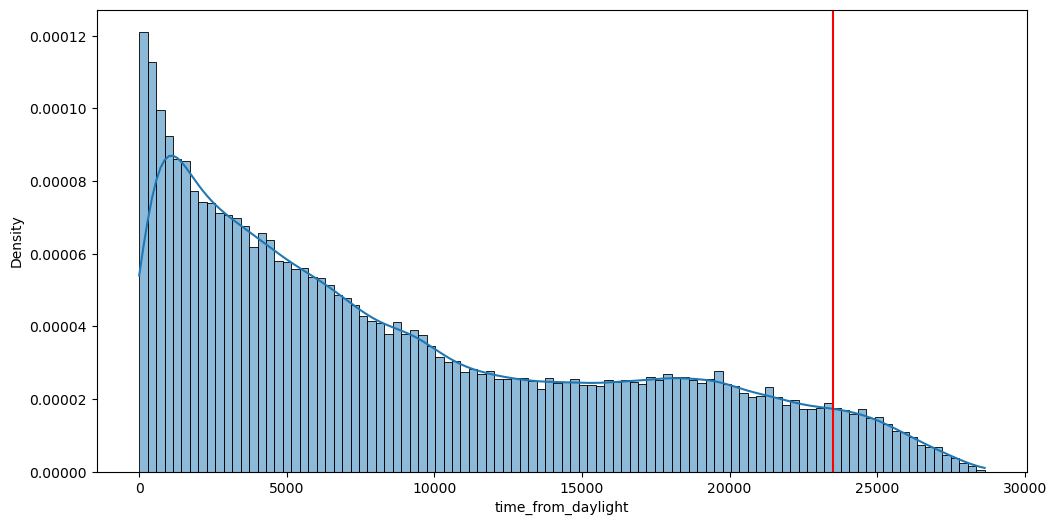

In [131]:
# plot of distribution of seconds from daylight, excluding the trips that occur during daylight
fig, ax = plot_density(df[df["time_from_daylight"] != 0]["time_from_daylight"])

In [132]:
show_summaries(df[~df["during_daylight"]], key="time_from_daylight")

,Car,Bike/Scooter,Walk,Transit
count,121938.000000,2115.000000,15504.000000,3990.000000
mean,9119.536191,9112.995745,9999.714590,7272.342607
std,7506.518388,7065.413273,7420.431555,6718.397844
min,0.000000,13.000000,0.000000,0.000000
25%,2736.000000,3066.500000,3425.000000,2149.500000
50%,6943.500000,7605.000000,8410.500000,4872.500000
75%,14731.000000,14064.500000,16342.500000,10437.500000
95%,23609.150000,22010.800000,23047.900000,21783.050000
max,28638.000000,28527.000000,28267.000000,28200.000000


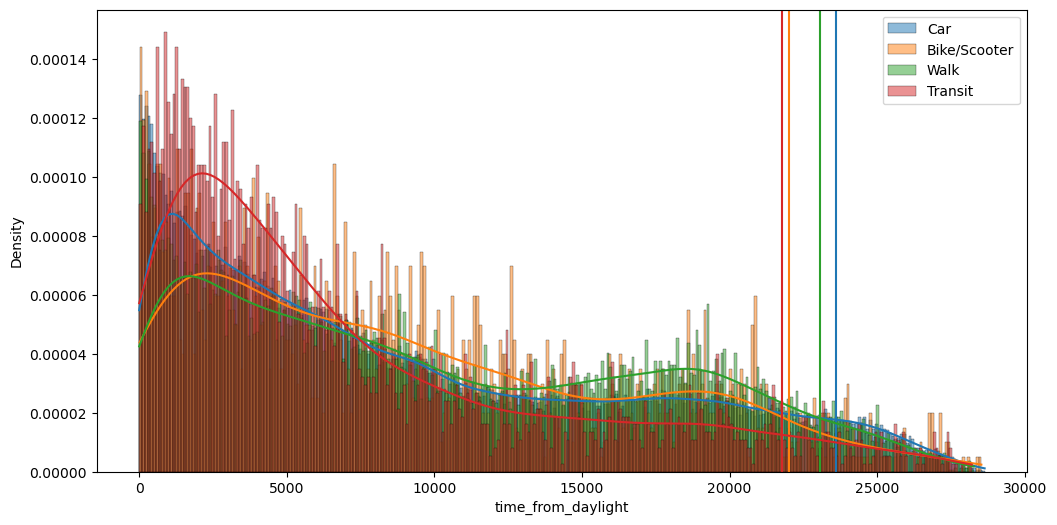

In [133]:
# seconds from daylight segmented by mode
# doesn't really make sense with 95th percetiles; distribution is also a bit iffy
fig, ax = plot_mode_density(df[df["time_from_daylight"] != 0], "time_from_daylight")
plt.legend()

takeaways

- is as expected -- trips shift to quicker/less vulnerable modes at nighttime
- time from daylight as a continuous metric isn't very meaningful
    - transit is the only that dips the most at longer times from daylight, likely affected by service availability

future analysis

- how to apply to feasibility analysis?
- we could make this more continuous
    - e.g., determine a good time from daylight measurement or just a general valid departure time range

### number of passengers

In [134]:
# overall analysis

In [135]:
# parsing into integer summary statistics
df[df["num_travelers"] != "Missing"]["num_travelers"].astype(int).describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    449976.000000
mean          1.813890
std           1.161894
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
95%           4.000000
max          11.000000
Name: num_travelers, dtype: float64

In [136]:
df["num_travelers_numeric"] = np.where(df["num_travelers"] == "Missing", -1, df["num_travelers"])
df["num_travelers_numeric"] = df["num_travelers_numeric"].astype(int)

<AxesSubplot:xlabel='num_travelers_numeric', ylabel='count'>

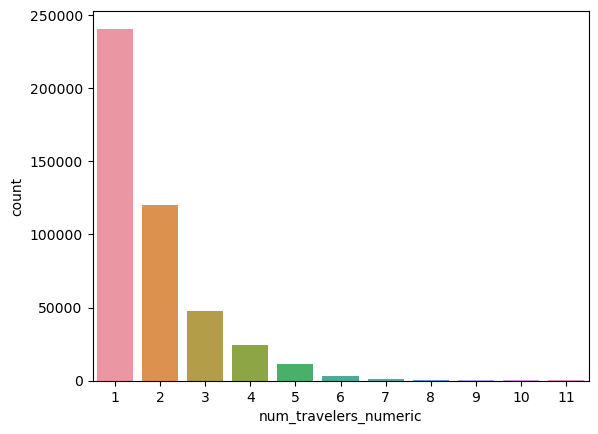

In [137]:
sns.countplot(x="num_travelers_numeric", data=df[df["num_travelers"] != "Missing"])

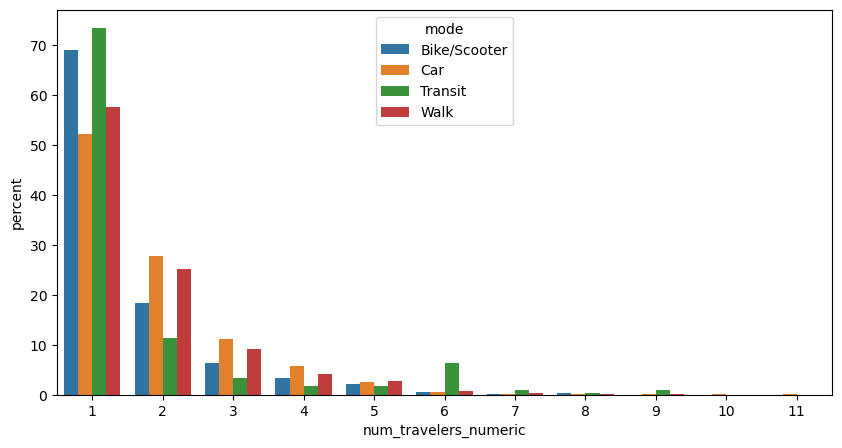

In [138]:
# side-by-side bar plot of the percentage of trips in each mode that have x travelers
# it seems car and walking are the dominant multi-traveler modes
# bike/scooter and transit are generally left-heavier, except for a seemingly random transit peak at 6 travelers
fig, ax = plot_multi_barplot(df[df["num_travelers"] != "Missing"], "num_travelers_numeric", "mode", figsize=(10, 5))

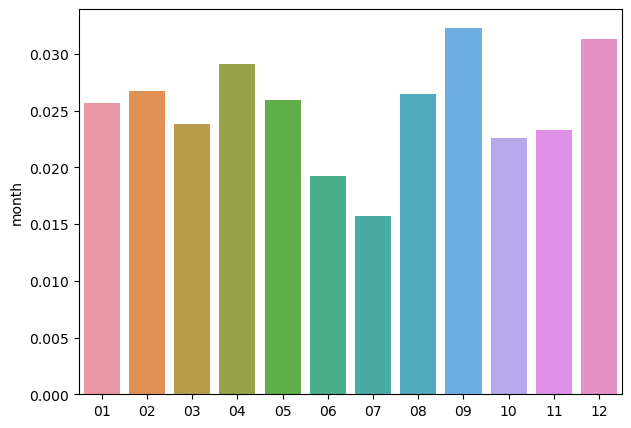

In [378]:
# transit months
fig, ax = plot_mode_barplot_pct_total(df, "month", "Transit", lambda x: x / df["month"].value_counts())

                   -1         1         2         3         4         5   \
Car           0.298298  0.816367  0.866962  0.880691  0.893989  0.835863   
Transit       0.023524  0.034284  0.010625  0.007648  0.007893  0.017194   
Bike/Scooter  0.005005  0.022074  0.011755  0.010302  0.010427  0.013861   
Walk          0.057558  0.119786  0.104343  0.096534  0.084742  0.118782   

                    6         7         8         9    10   11  
Car           0.456327  0.542020  0.539370  0.411585  1.0  1.0  
Transit       0.204670  0.078643  0.074803  0.292683  NaN  NaN  
Bike/Scooter  0.010378  0.008481  0.035433       NaN  NaN  NaN  
Walk          0.107812  0.121820  0.129921  0.097561  NaN  NaN  
-1     0.298298
 1     0.816367
 2     0.866962
 3     0.880691
 4     0.893989
 5     0.835863
 6     0.456327
 7     0.542020
 8     0.539370
 9     0.411585
 10    1.000000
 11    1.000000
Name: num_travelers_numeric, dtype: float64


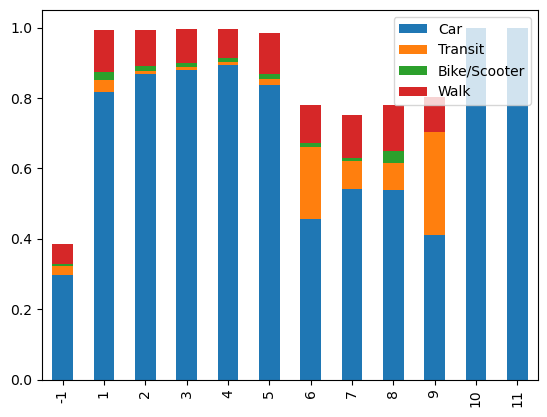

In [415]:
# stacked mode share (% of trips in each number of travelers that have a given mode)
# ignore -1; means missing
plot_stacked_mode_share("num_travelers_numeric")

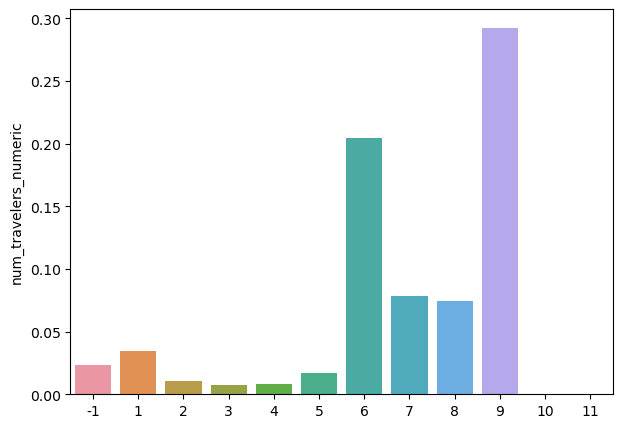

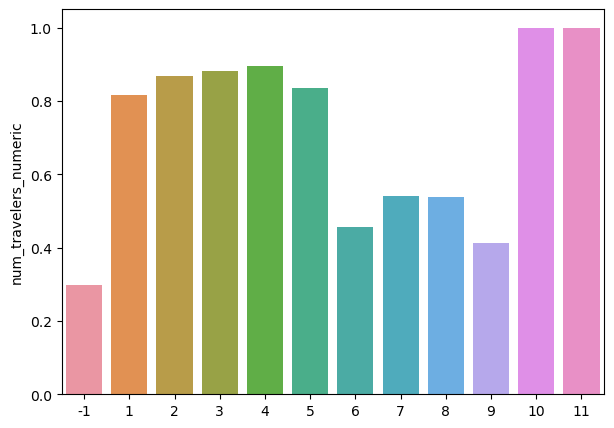

In [377]:
fig, ax = plot_mode_barplot_pct_total(df, "num_travelers_numeric", "Transit", lambda x: x / df["num_travelers_numeric"].value_counts())
x, y = plot_mode_barplot_pct_total(df, "num_travelers_numeric", "Car", lambda x: x / df["num_travelers_numeric"].value_counts())

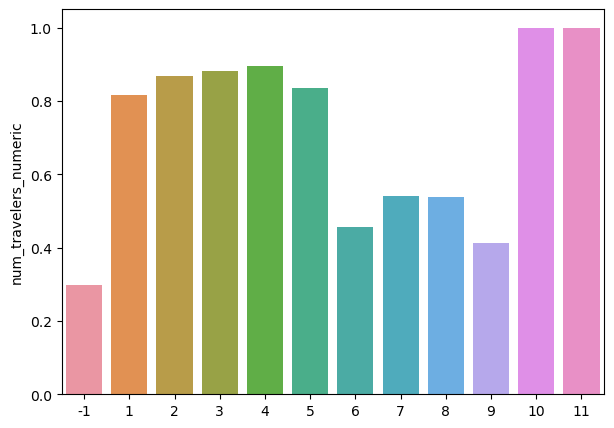

In [374]:
fig, ax = plot_mode_barplot_pct_total(df, "num_travelers_numeric", "Car", lambda x: x / df["num_travelers_numeric"].value_counts())

In [139]:
# summary statistics of the number of travelers for eahc mode
show_summaries(df[df["num_travelers"] != "Missing"], key="num_travelers_numeric")

,Car,Bike/Scooter,Walk,Transit
count,376737.000000,7695.000000,50019.00000,11232.000000
mean,1.816418,1.539311,1.73564,1.761663
std,1.117541,1.025909,1.13261,1.647639
min,1.000000,1.000000,1.00000,1.000000
25%,1.000000,1.000000,1.00000,1.000000
50%,1.000000,1.000000,1.00000,1.000000
75%,2.000000,2.000000,2.00000,2.000000
95%,4.000000,4.000000,4.00000,6.000000
max,11.000000,8.000000,9.00000,9.000000


takeaways

- transit/biking are modes generally associated with less travelers while walking/driving are hte opposite
    - there are deviations from this trend -- e.g., the dominance of transit from 6-9 travelers (college students? or groups of people going somewhere without cars)

future analysis
- 95% rule probably won't work here -- it's not really reasonable to assume anybody with 4 travelers can just ride via bike/scooter
    - percentiles aren't also necessarily the best here -- data is ordinal, not continuous; need more robust metric for number of people
- possibly go into more detail with number of children/non-household members as well

### traveler details (age, disability status, ability to drive)

In [140]:
# traveler ability to drive

In [141]:
df["can_drive"].value_counts()

Yes, drives           382305
No, does not drive     54309
Missing                15360
Name: can_drive, dtype: int64

<AxesSubplot:xlabel='can_drive', ylabel='count'>

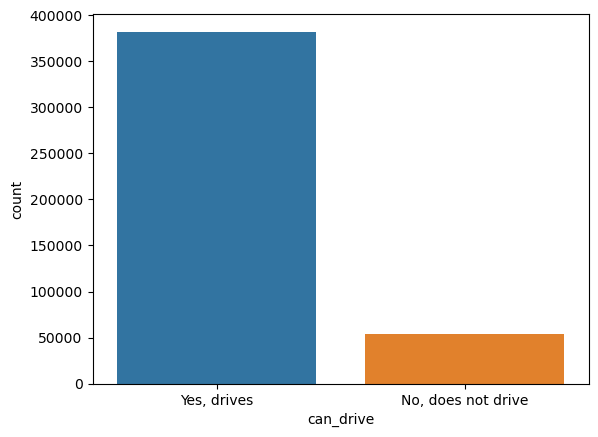

In [142]:
# bar plot of can drive vs can't drive
# most people can drive
# does htis include car ownership or just license?
sns.countplot(x="can_drive", data=df[df["can_drive"] != "Missing"])

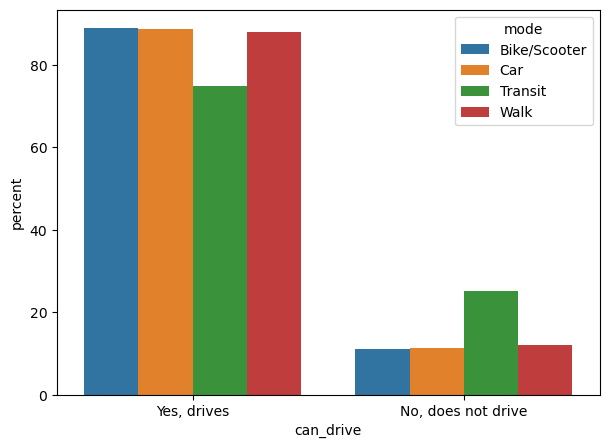

In [143]:
# side by side bar plot of the % of epople in each mode who can drive/can't drive
# relatively uniform aside from transit -- people who can drive have a lesser tendency to not use transit & vice versa
# transit may directly substitute car trips while other modes simply complement them
fig, ax = plot_multi_barplot(df[df["can_drive"] != "Missing"], "can_drive", "mode")

In [144]:
# number of vehicles -- only accounts for household, not whether an individual can drive (has license)

In [145]:
# get into a numeric form
df["num_vehicles_numeric"] = np.where(df["num_vehicles"] == "8+", 10, df["num_vehicles"].replace("8+", 9).astype(int))

<Axes: xlabel='num_vehicles_numeric', ylabel='count'>

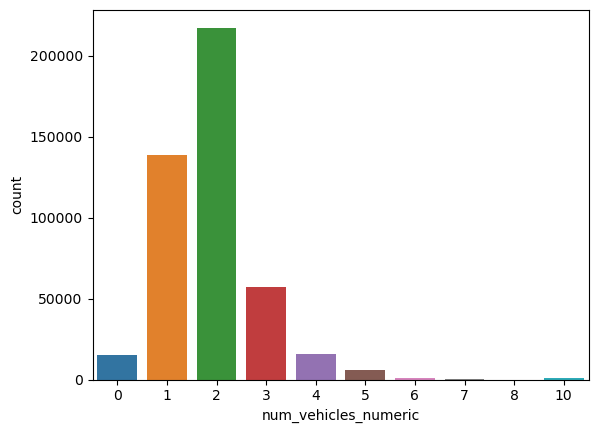

In [146]:
sns.countplot(x="num_vehicles_numeric", data=df)

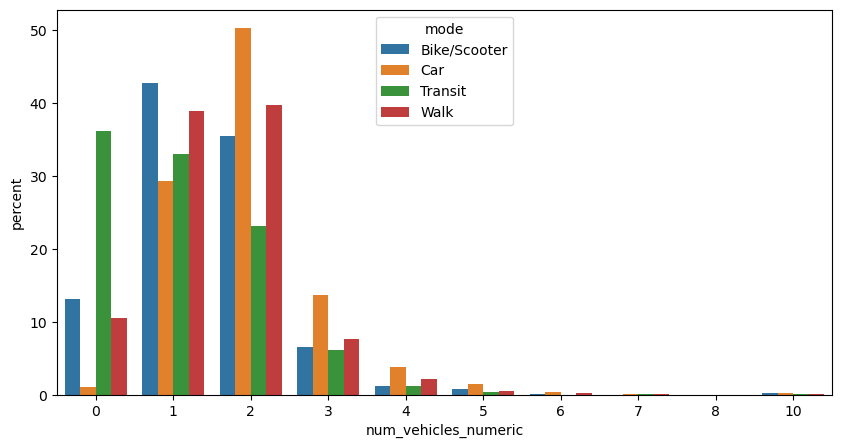

In [147]:
# analysis on number of vehicles
fig, ax = plot_multi_barplot(df, "num_vehicles_numeric", "mode", figsize=(10, 5))

In [148]:
# age analysis

In [149]:
df["age"].value_counts()

35-44          58536
25-34          54345
55-64          47780
45-54          43498
35 to 44       34806
25 to 34       33183
65-74          30543
5-15           27564
55 to 64       20739
45 to 54       20679
Under 5        20296
65 to 74       16596
18-24          12359
5 to 15         8991
18 to 24        7637
75 or older     6890
75 to 84        3466
16-17           3199
16 to 17         672
85 or older      195
Name: age, dtype: int64

In [150]:
# merge the two different labeling schemes
df["age_cleaned"] = df["age"].apply(lambda x: '-'.join(x.split(" to ")))
df["age_cleaned"] = np.where(df["age_cleaned"] == "5-15", "05-15", df["age_cleaned"])
df["age_cleaned"] = np.where(df["age_cleaned"] == "Under 5", "00-05", df["age_cleaned"])

<Axes: xlabel='age_cleaned', ylabel='count'>

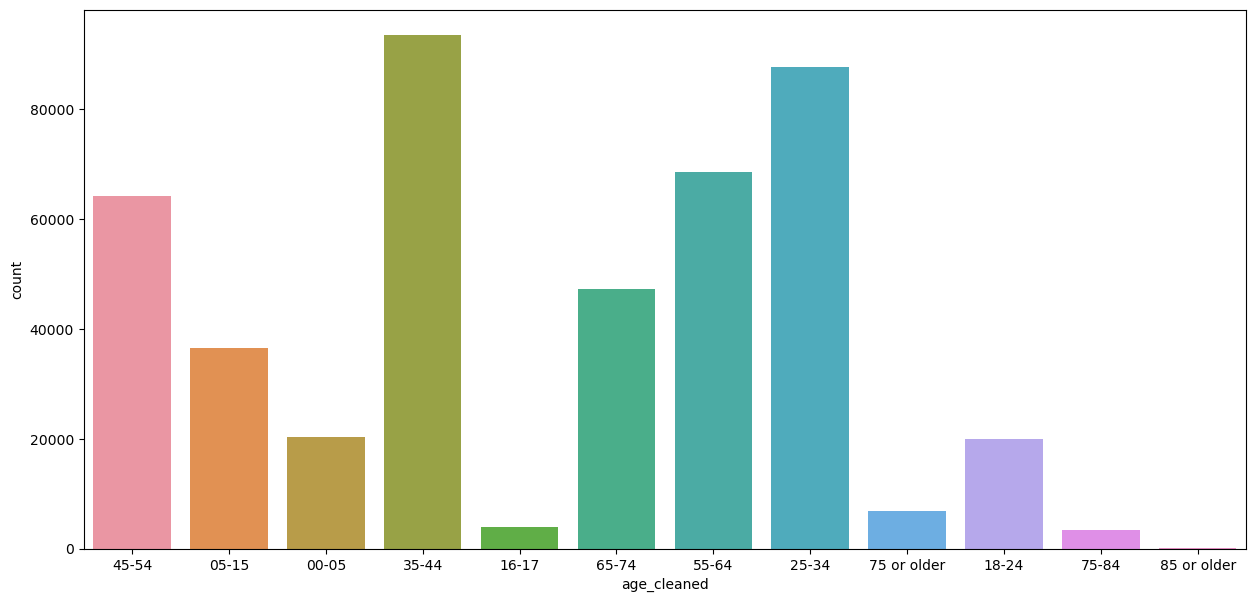

In [151]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.countplot(x="age_cleaned", data=df, ax=ax)

(<Figure size 1500x700 with 1 Axes>,
 <Axes: xlabel='age_cleaned', ylabel='percent'>)

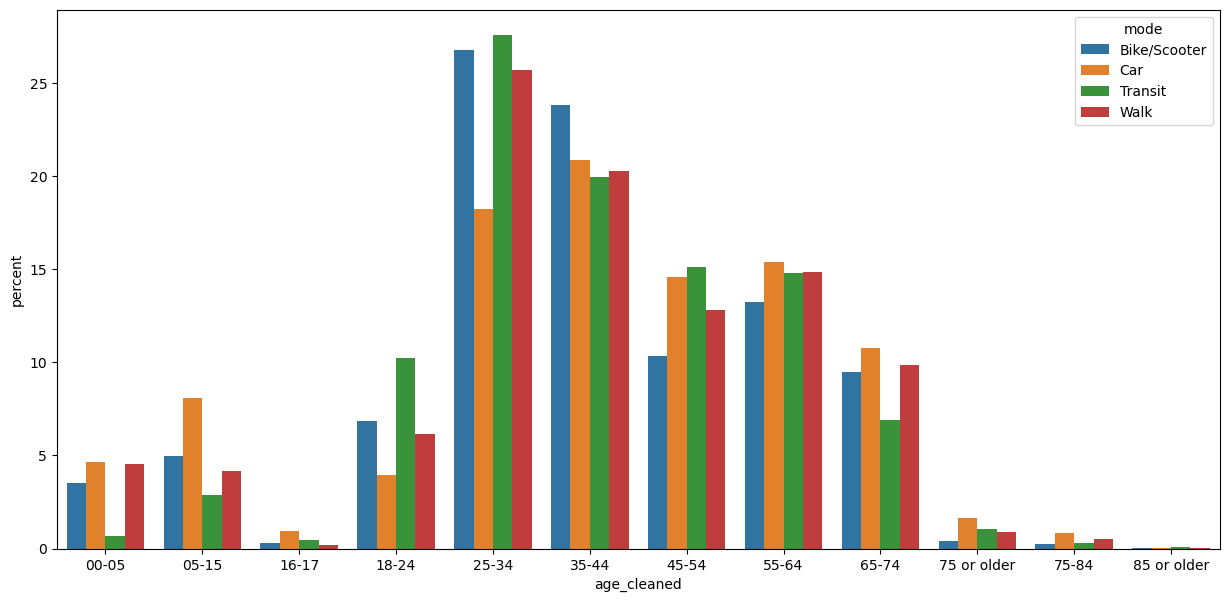

In [152]:
# side by side bar plot of the % of trips of each mode that were made by certain age groups
# generally, car usage is less dominant from 18-44, after which car becomes more dominant
# transit usage decays from a peak in 25-34
plot_multi_barplot(df, "age_cleaned", y="mode", figsize=(15, 7), order=df["age_cleaned"].value_counts().sort_index().index)

In [153]:
# age - can't really rule out anything
    # maybe old people can't bike
# one record for each person id -- both

In [154]:
# disability

In [155]:
df["disability"].value_counts()

No                       367980
Missing: Skip logic       45407
Missing                   16171
Yes                       14387
Prefer not to answer       6593
Missing: Non-response      1436
Name: disability, dtype: int64

In [156]:
# clean all missing things into one NA value
df["disability_cleaned"] = np.where(df["disability"].isin(["No", "Yes"]), df["disability"], "NA")

In [157]:
df["disability_cleaned"].value_counts()

No     367980
NA      69607
Yes     14387
Name: disability_cleaned, dtype: int64

<Axes: xlabel='disability_cleaned', ylabel='count'>

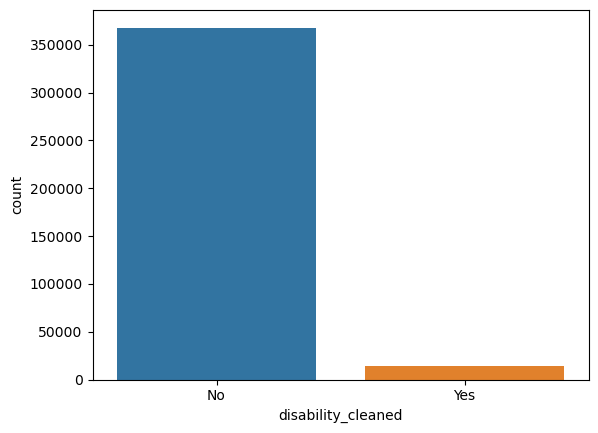

In [158]:
sns.countplot(x="disability_cleaned", data=df[df["disability_cleaned"] != "NA"])

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='disability_cleaned', ylabel='percent'>)

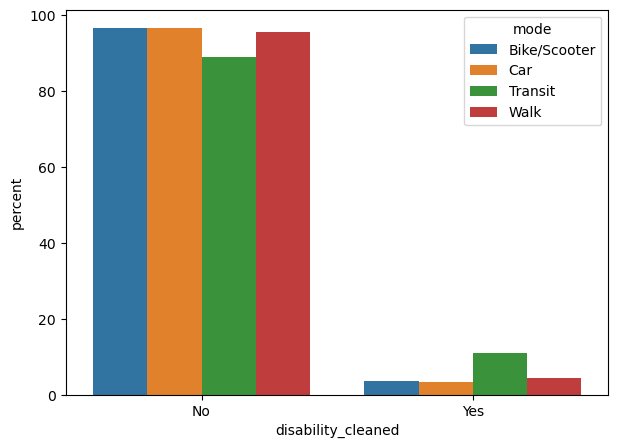

In [159]:
# side by side bar plot of the % of trips via each mode who do/do not have disabilities
# similar trend to those without cars -- those with disabilities tend to travel via transit, with everything else uniform
plot_multi_barplot(df[df["disability_cleaned"] != "NA"], "disability_cleaned", "mode")

takeaways
- those who cannot drive/are disabled have a greater likelihood of choosing transit, although not very significantly
    - mirrored by vehicle count somewhat, but this variable is less individualized than these
    - there is likely some overlap between these groups
    - with these variables, all other modes are uniform -- there is something unique about transit in catering to these people
- the relationship between age & mode choice/preferences are complex, but there definitely do seem to be patterns

future analysis
- possibly explore more personal variables
- can explore the combination of personal variables with other ones
    - e.g., people with disabilities that have multiple people in their household/travel with multiple people often

### bike lts share

**note:** this relies heavily on the assumptions made in bike routing and more reflect the design deatils of that optimization; any cutoff isn't based on data

In [160]:
bike["lts1"] = bike["distance_meters_1"] / bike["distance_meters"]
bike["lts2"] = bike["distance_meters_2"] / bike["distance_meters"]
bike["lts3"] = bike["distance_meters_3"] / bike["distance_meters"]
bike["lts4"] = bike["distance_meters_4"] / bike["distance_meters"]

In [161]:
df[df["mode"] == "Bike/Scooter"]["distance"] - bike.set_index('trip_id').loc[df[df["mode"] == "Bike/Scooter"].trip_id]['distance_meters']

267               NaN
268               NaN
269               NaN
272               NaN
273               NaN
                   ..
[2200278603002]   NaN
[2200278802001]   NaN
[2200278802002]   NaN
[2200279102001]   NaN
[2200279102002]   NaN
Length: 15410, dtype: float64

In [162]:
bike

,trip_id,duration_seconds,distance_meters,weight,distance_meters_1,distance_meters_2,distance_meters_3,distance_meters_4,geometry,lts1,lts2,lts3,lts4
0,[1811206201001],21781.8,35771.3,14002.7,31340.529135,298.150005,3734.391881,397.351353,"LINESTRING (-92.76557 44.65391, -92.76603 44.6...",0.876136,0.008335,0.104396,0.011108
1,[1811206201002],21781.8,35771.3,14002.7,31340.529135,298.150005,3734.391881,397.351353,"LINESTRING (-92.91715 44.51007, -92.91576 44.5...",0.876136,0.008335,0.104396,0.011108
2,[1811206203001],15218.0,25992.0,10165.6,24928.078483,298.150005,129.130877,636.653314,"LINESTRING (-92.76557 44.65391, -92.76603 44.6...",0.959067,0.011471,0.004968,0.024494
3,[1811206203002],15241.3,25997.8,10172.9,24933.897999,298.150005,129.130877,636.653314,"LINESTRING (-92.88609 44.73583, -92.88572 44.7...",0.959077,0.011468,0.004967,0.024489
4,[1811206204001],13104.0,23178.3,8545.7,22358.880570,298.150005,85.485012,435.807499,"LINESTRING (-92.76557 44.65391, -92.76603 44.6...",0.964647,0.012863,0.003688,0.018802
...,...,...,...,...,...,...,...,...,...,...,...,...,...
458633,[2200279003003],6138.5,13541.8,2782.3,11780.143850,1689.470227,44.290975,27.871214,"LINESTRING (-93.14578 44.91527, -93.14603 44.9...",0.869910,0.124760,0.003271,0.002058
458634,[2200279101001],8034.1,14334.2,4315.9,13878.443165,0.000000,225.336566,230.453257,"LINESTRING (-93.38229 45.04008, -93.38164 45.0...",0.968205,0.000000,0.015720,0.016077
458635,[2200279101002],8034.1,14334.2,4315.9,13878.443165,0.000000,225.336566,230.453257,"LINESTRING (-93.35434 45.07169, -93.35359 45.0...",0.968205,0.000000,0.015720,0.016077
458636,[2200279102001],4119.1,7267.8,2545.0,6976.301425,68.723028,7.893996,214.921328,"LINESTRING (-93.38229 45.04008, -93.38164 45.0...",0.959892,0.009456,0.001086,0.029572


In [163]:
bike_lts_share = bike.set_index("trip_id").loc[df[df["mode"] == "Bike/Scooter"].trip_id][["lts1", "lts2", "lts3", "lts4", "distance_meters_1", "distance_meters_2", "distance_meters_3", "distance_meters_4"]]

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts1', ylabel='Density'>)

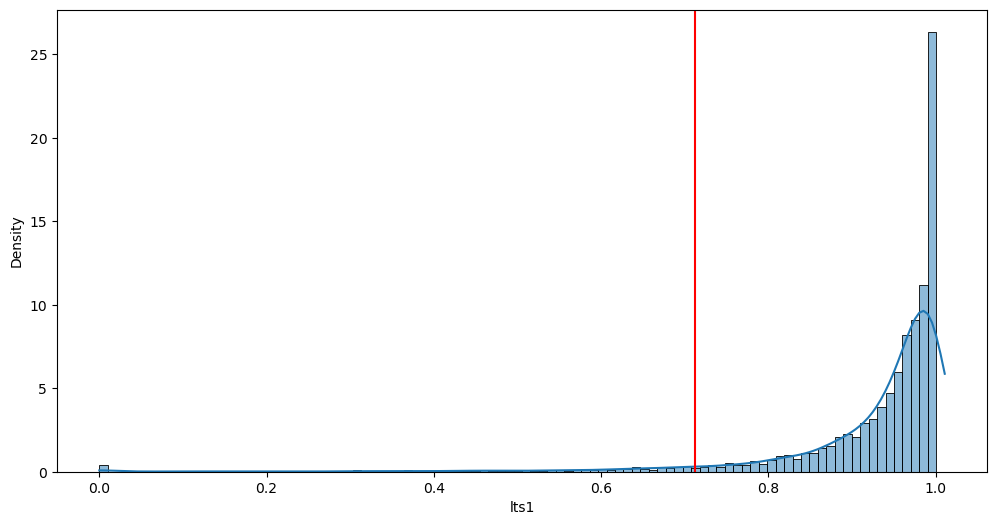

In [164]:
# distribution of % of trip taken in lts1, very right-heavy
# 0.05 percentile is effectively the 95th here
plot_density(bike_lts_share["lts1"], percentile=0.05)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='distance_meters_1', ylabel='Density'>)

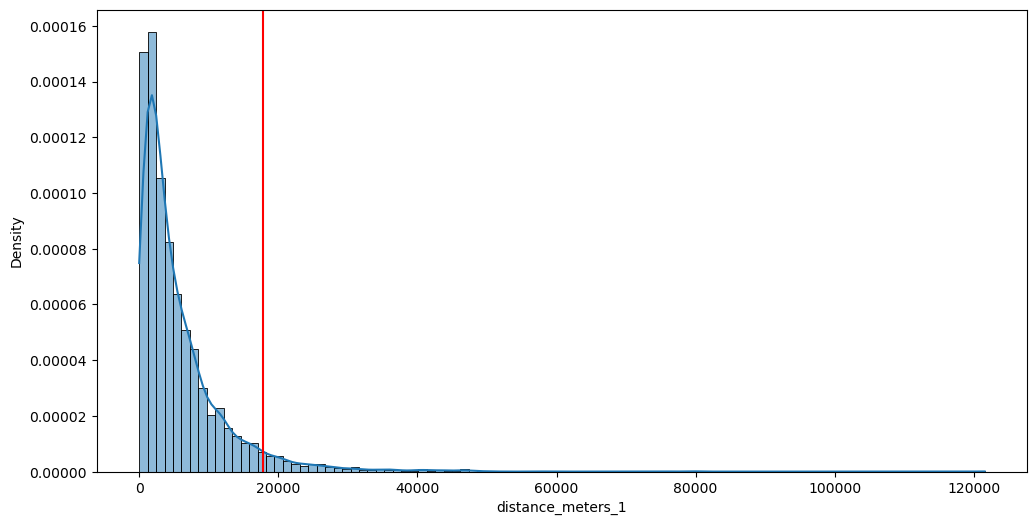

In [213]:
# distribution of distance taken in lts1, very left-heavy
plot_density(bike_lts_share["distance_meters_1"])

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts2', ylabel='Density'>)

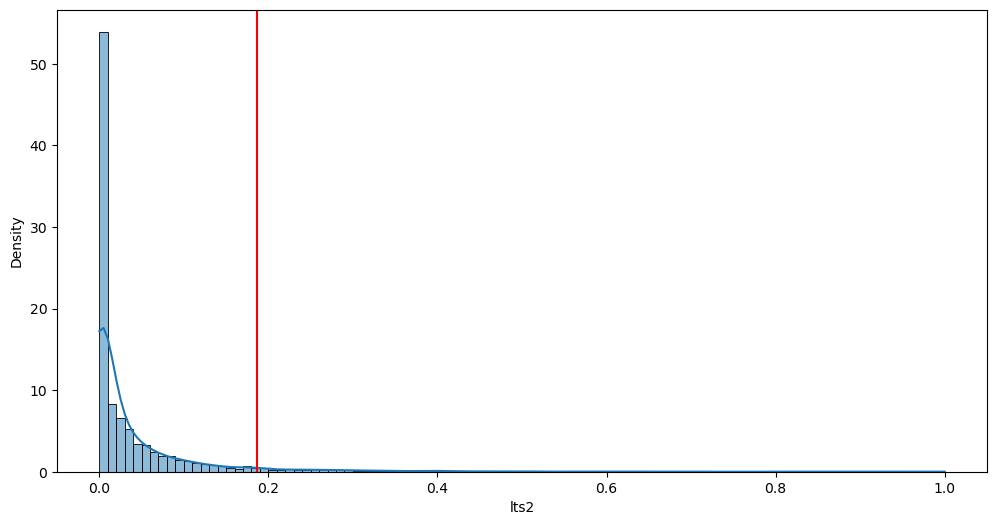

In [166]:
# distribution of % of trip taken in lts2, left-heavy
plot_density(bike_lts_share["lts2"])

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='distance_meters_2', ylabel='Density'>)

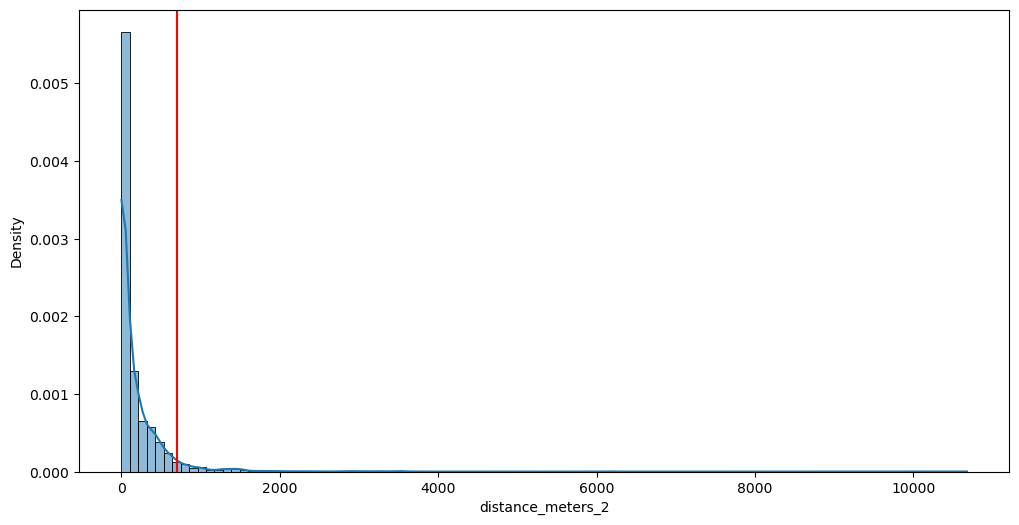

In [167]:
# distribution of distance of trip taken in lts2
plot_density(bike_lts_share["distance_meters_2"], percentile=0.95)

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts3', ylabel='Density'>)

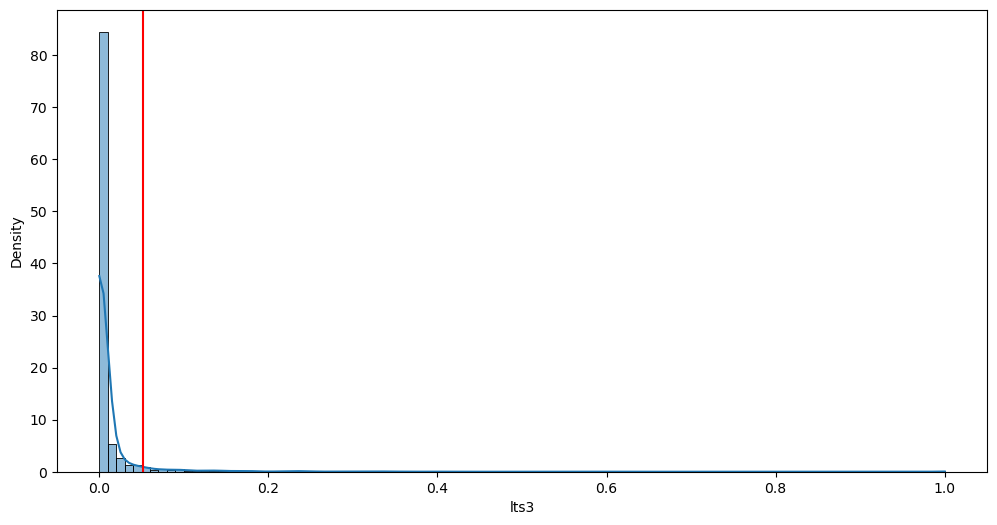

In [168]:
# distribution of % of trip taken in lts3
# like lts2 but more left-heavy
plot_density(bike_lts_share["lts3"])

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='distance_meters_3', ylabel='Density'>)

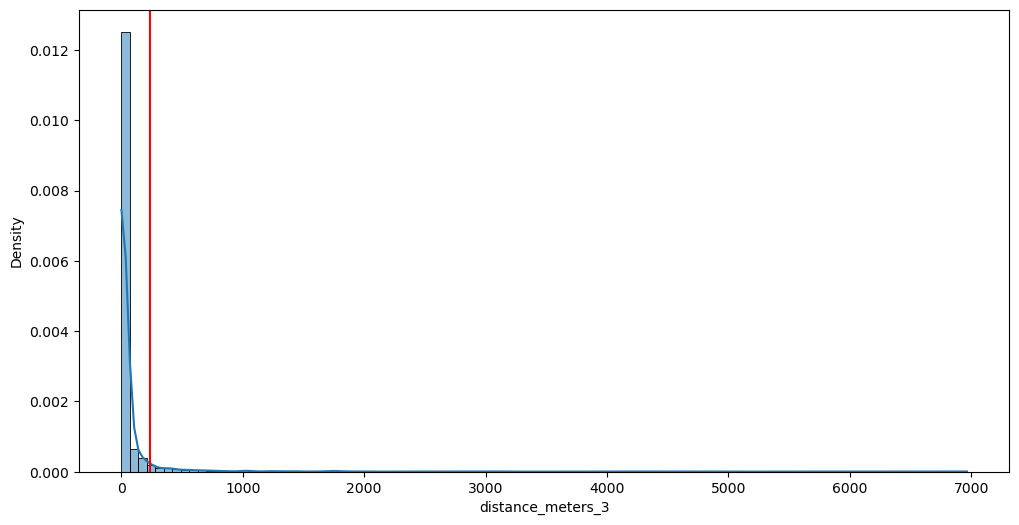

In [169]:
# distribution of distances traveled in lts3
plot_density(bike_lts_share["distance_meters_3"], percentile=0.95)

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='lts4', ylabel='Density'>)

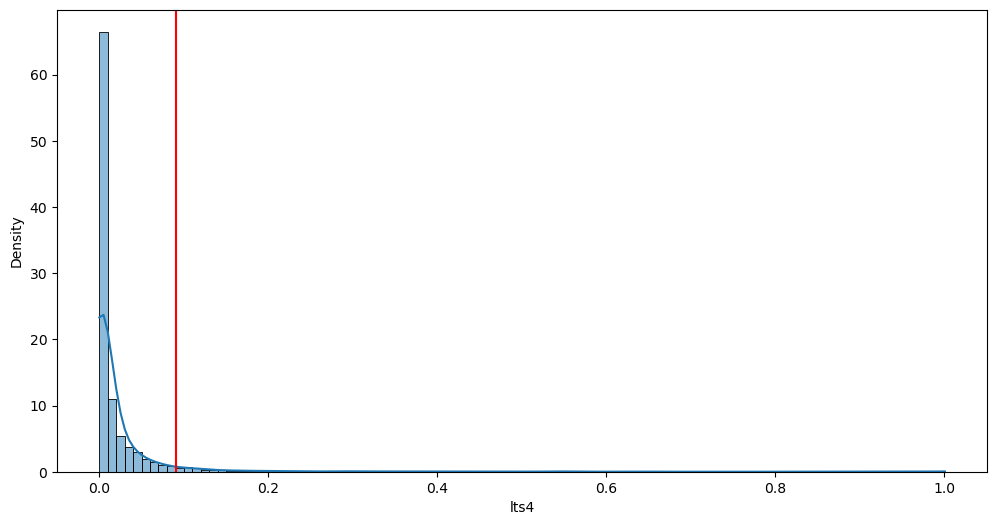

In [170]:
# distribution of % of trip taken in lts4
# like lts3 but more left-heavy
plot_density(bike_lts_share["lts4"])

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='distance_meters_4', ylabel='Density'>)

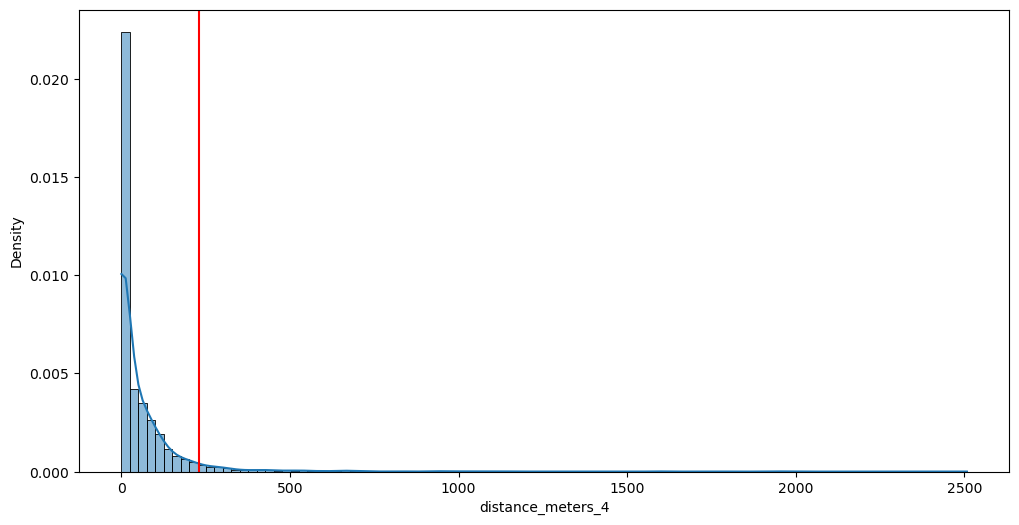

In [171]:
# distribution of amount of trip taken in lts1
plot_density(bike_lts_share["distance_meters_4"], percentile=0.95)

takeaways

- lts % is a strong measure of biking feasibility -- the vast majoirty of trips should be done mostly (w.r.t distance) on lts 1 paths
- lts distances generally cluster towards 0 as the lts increases
- as lts increases, the share of the distance on that lts generally decreases

future analysis
- elevation change

### day of week

In [172]:
# could be meaningful analysis but not necessarily related to feasibility

In [173]:
df["travel_dow"].value_counts()

Tuesday      74861
Thursday     73664
Wednesday    73294
Friday       63573
Saturday     60023
Monday       57345
Sunday       49214
Name: travel_dow, dtype: int64

<Axes: xlabel='travel_dow', ylabel='count'>

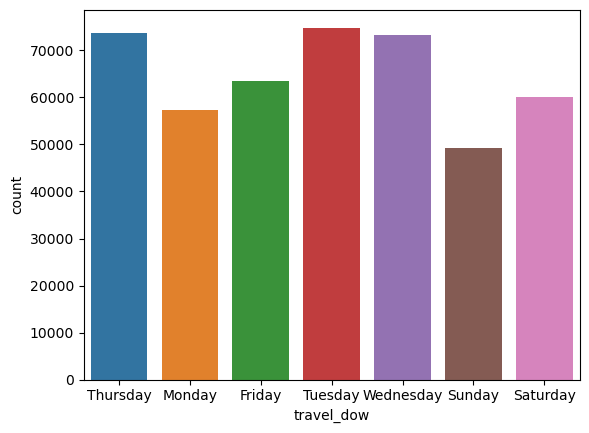

In [174]:
sns.countplot(x="travel_dow", data=df)

(<Figure size 700x500 with 1 Axes>, <Axes: ylabel='travel_dow'>)

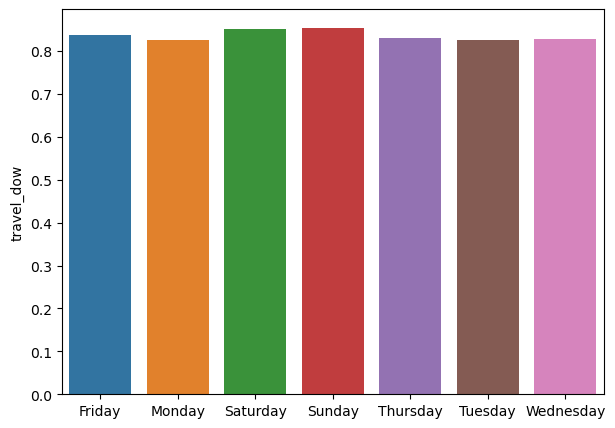

In [175]:
# mode share of car by day of week
# generally flat
plot_mode_barplot_pct_total(df, "travel_dow", "Car", func=lambda x: x / df["travel_dow"].value_counts())

(<Figure size 700x500 with 1 Axes>, <Axes: ylabel='travel_dow'>)

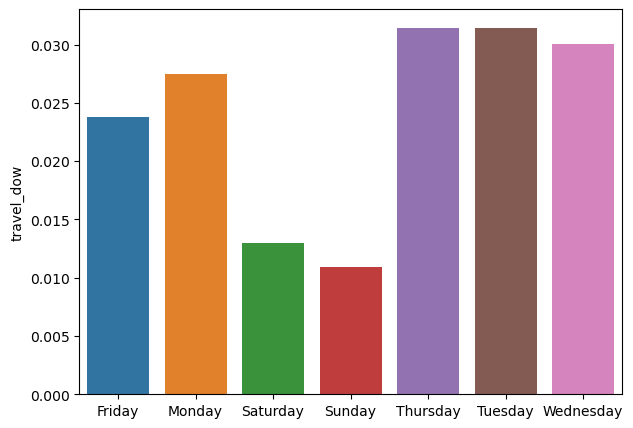

In [176]:
# mode share of transit by day of week
# sharp dip in saturday/sunday -- loss in service
plot_mode_barplot_pct_total(df, "travel_dow", "Transit", func=lambda x: x / df["travel_dow"].value_counts())

(<Figure size 700x500 with 1 Axes>, <Axes: ylabel='travel_dow'>)

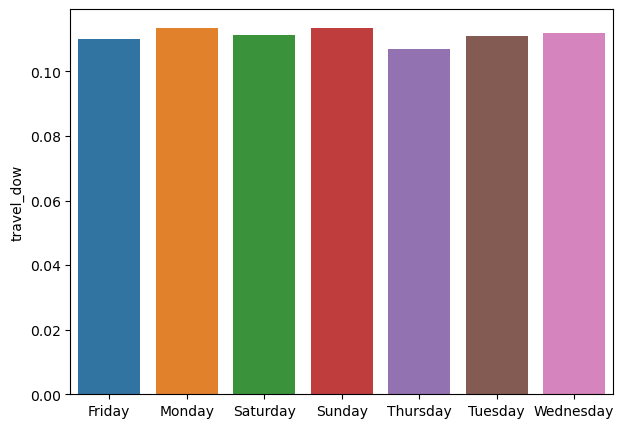

In [177]:
# mode share of walking by day of week
# also generally stable
plot_mode_barplot_pct_total(df, "travel_dow", "Walk", func=lambda x: x / df["travel_dow"].value_counts())

(<Figure size 700x500 with 1 Axes>, <Axes: ylabel='travel_dow'>)

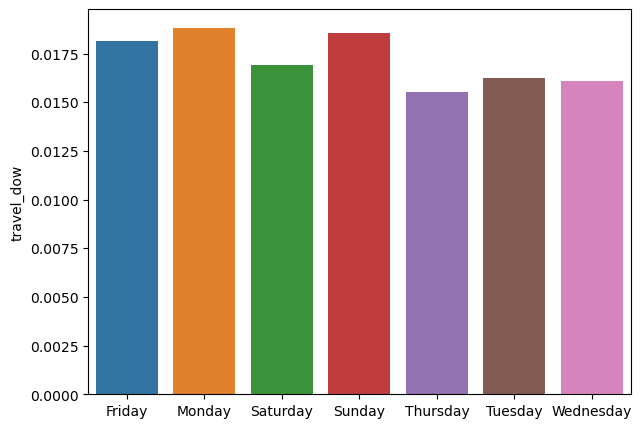

In [178]:
# mode share of biking by day of week
# mostly stable, but with dips in the middle of the week
plot_mode_barplot_pct_total(df, "travel_dow", "Bike/Scooter", func=lambda x: x / df["travel_dow"].value_counts())

day of week takeaways

- mode share does seem to change with the days of the week
- walk/driving is day-invariant while biking/transit are more dependent

### purpose

In [179]:
# merging some closely related categories
df["purpose_cleaned"] = df["d_purpose_category"]
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["School", "School-related"]), "School", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Work", "Work-related"]), "Work", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Errand/Other", "Errand"]), "Errand", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Shop", "Shopping"]), "Shop", df["purpose_cleaned"])
df["purpose_cleaned"] = np.where(df["purpose_cleaned"].isin(["Missing: Non-response", "Missing: Skip logic", "Not imputable"]), "Missing", df["purpose_cleaned"])

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'Work'),
  Text(1, 0, 'Home'),
  Text(2, 0, 'School'),
  Text(3, 0, 'Shop'),
  Text(4, 0, 'Social/Recreation'),
  Text(5, 0, 'Errand'),
  Text(6, 0, 'Meal'),
  Text(7, 0, 'Escort'),
  Text(8, 0, 'Change mode'),
  Text(9, 0, 'Overnight'),
  Text(10, 0, 'Other')])

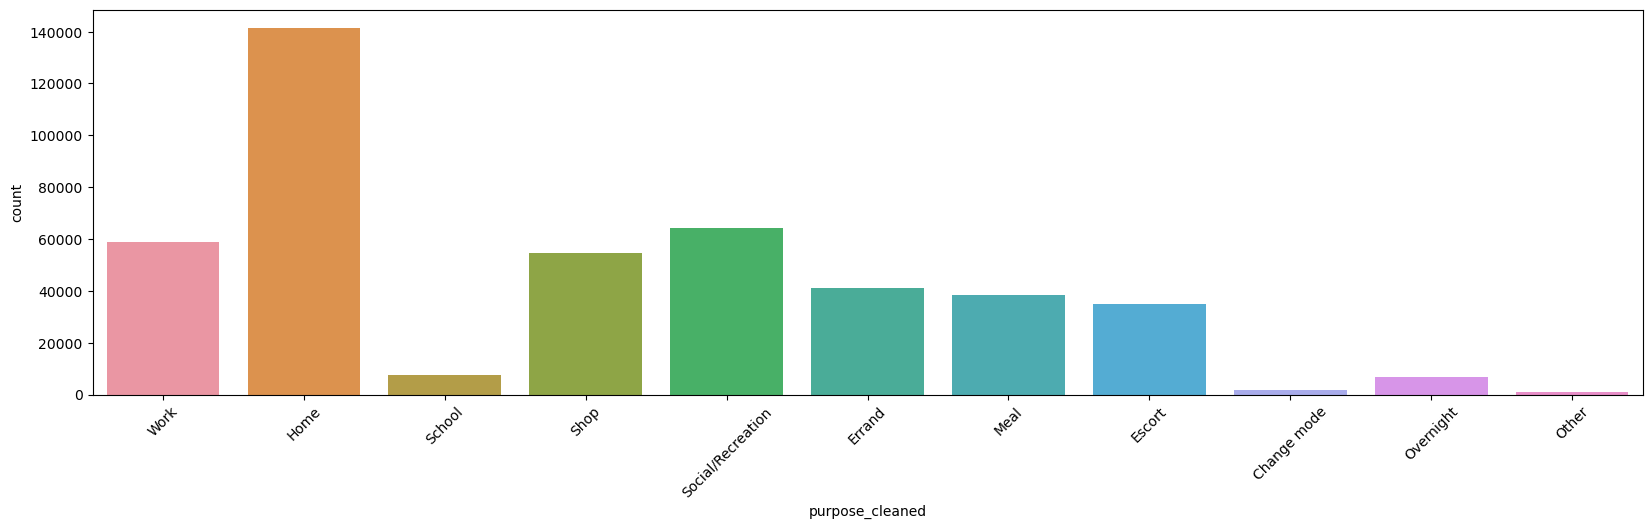

In [180]:
# overall distribution
fig, ax = plt.subplots(figsize=(20, 5))
sns.countplot(x="purpose_cleaned", data=df[df["purpose_cleaned"] != "Missing"], ax=ax)
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'Home'),
  Text(1, 0, 'Social/Recreation'),
  Text(2, 0, 'Work'),
  Text(3, 0, 'Shop'),
  Text(4, 0, 'Meal'),
  Text(5, 0, 'Errand'),
  Text(6, 0, 'School'),
  Text(7, 0, 'Escort'),
  Text(8, 0, 'Overnight'),
  Text(9, 0, 'Change mode'),
  Text(10, 0, 'Other')])

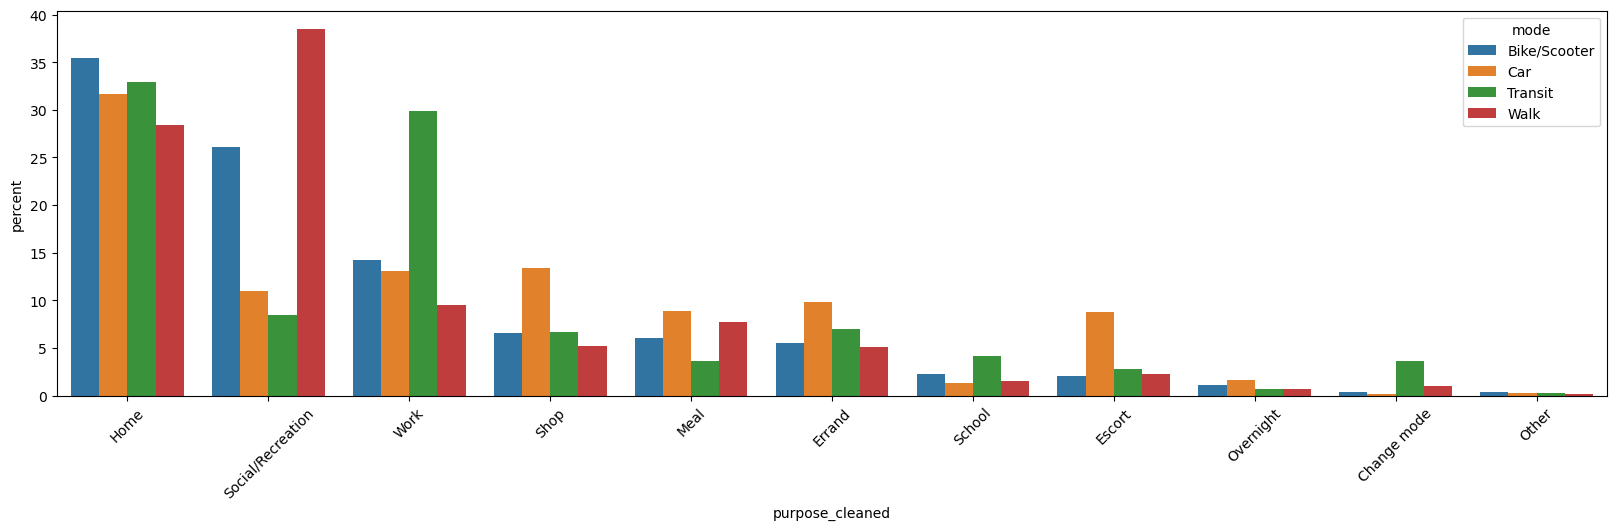

In [181]:
# purpose segmented by mode -- % of all mode trips in each purpose category
# notable features: social/recreation is predominantly walking, errands/shopping/escorts are mostly car
fig, ax = plot_multi_barplot(df[df["purpose_cleaned"] != "Missing"], "purpose_cleaned", "mode", figsize=(20, 5))
plt.xticks(rotation=45)

purpose takeaways

- some purposes are dominated by certain modes
    - things like going home are relatively mode-agnostic
    - going to work draws a higher proportion of transit trips
    - shopping draws a higher proportion of car trips
    - vast majority of walk trips are made for social/recreational trips

future analysis
- detailed purposes? or some recoding

### generalized weight (bike/walk)

**note**: these more reflect the routing metholodology as opposed to the real behavior observed in the data

In [182]:
# bike weight summary
bike["weight"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    458638.000000
mean       4539.016225
std        5258.289682
min           0.000000
25%        1436.400000
50%        2911.300000
75%        5647.700000
95%       14262.180000
max       74644.200000
Name: weight, dtype: float64

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='weight', ylabel='Density'>)

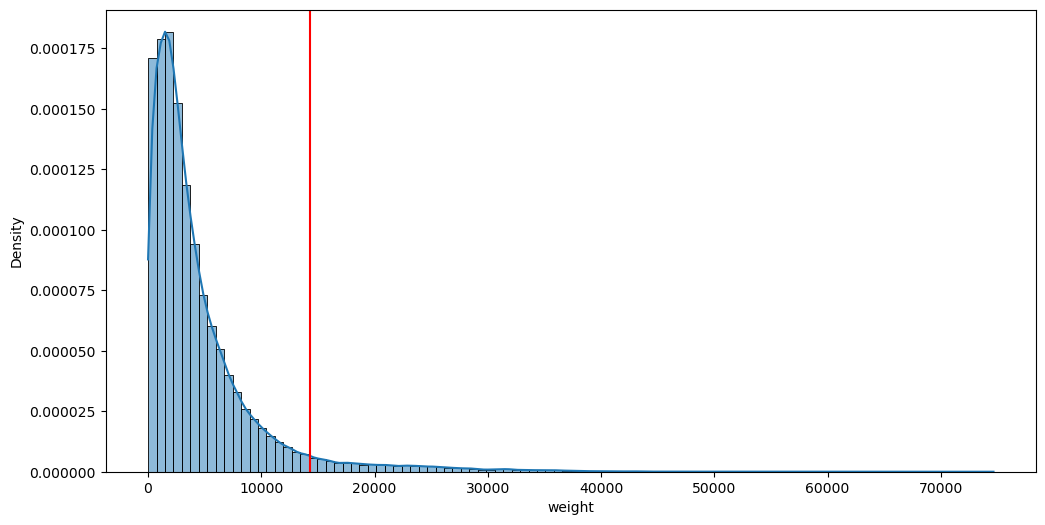

In [183]:
# bike generalized weight distribution
plot_density(bike["weight"])

In [184]:
# walking generalized weights summary
walk["weight"].describe()

count    458650.000000
mean       6932.603913
std        9330.964805
min           0.000000
25%        1289.900000
50%        3550.000000
75%        8777.300000
max      131635.900000
Name: weight, dtype: float64

(<Figure size 1200x600 with 1 Axes>, <Axes: xlabel='weight', ylabel='Density'>)

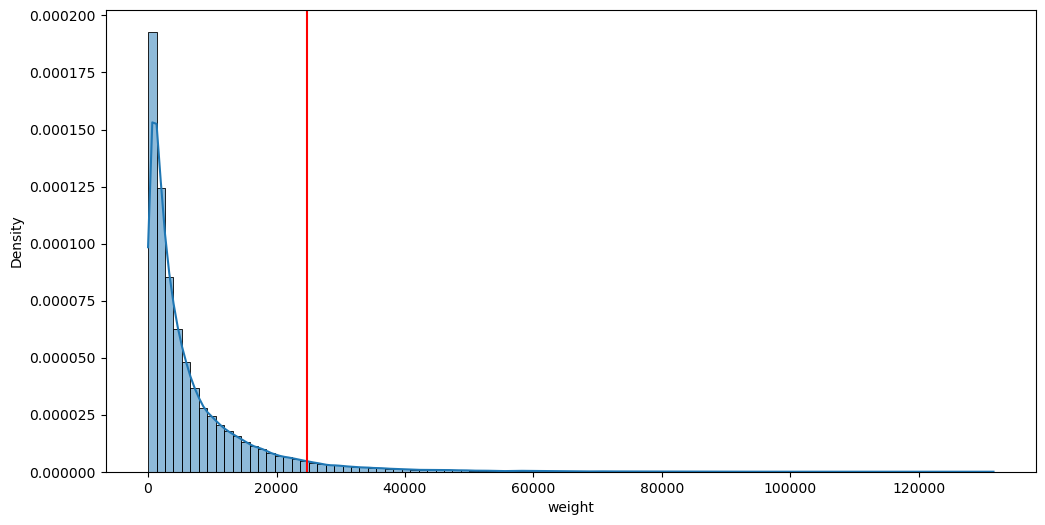

In [185]:
# walking generalized weights distribution
plot_density(walk["weight"])

takeaways

- lower weights are generally favored
- not sure if weight scales are transferred across modes
- this relies on rerouting analyses and not the ground truth of the surveys -- possibly biased/not reflective of real choices

### transit trip specifics -- transfers, legs, walking time

In [ ]:
# use the raw tbi data, which contains canonical details on egress/access and number of legs

In [345]:
wave1_trips = pd.read_csv(data_dir + "/Data/TBI Wave 1 Dataset 20200630/trip.csv")
wave2_trips = pd.read_csv(data_dir + "/Data/Wave 2 Data Deliverable/trip.csv")
raw_trips = pd.concat([wave1_trips, wave2_trips]).set_index("trip_id")
raw_trips

C:\Users\yianz\AppData\Local\Temp\ipykernel_19512\3580572735.py:1: DtypeWarning: Columns (71,72) have mixed types. Specify dtype option on import or set low_memory=False.
  wave1_trips = pd.read_csv(data_dir + "/Data/TBI Wave 1 Dataset 20200630/trip.csv")


,person_id,trip_num,hh_id,participation_group,person_num,day_num,travel_date,travel_dow,hh_day_complete,day_complete,...,ev_charge_station_decision,ev_charge_station_level_1,ev_charge_station_level_2,ev_charge_station_level_3,ev_charge_station_level_998,o_zone,d_zone,linked_trip_id,leg_id,vehicle_id
trip_id,,,,,,,,,,,,,,,,,,,,,
1814439301001,1814439301,1,18144393,1.0,1,1,2018-10-22,1,1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1814439301002,1814439301,2,18144393,1.0,1,1,2018-10-22,1,1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1814439301003,1814439301,3,18144393,1.0,1,1,2018-10-22,1,1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1814439301004,1814439301,4,18144393,1.0,1,2,2018-10-23,2,1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1814439301005,1814439301,5,18144393,1.0,1,2,2018-10-23,2,1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200279003003,2200279003,3,22002790,NaN,3,1,2022-01-27,4,1,NaN,...,995.0,995.0,995.0,995.0,995.0,5.0,5.0,212556.0,1.0,NaN
2200279101001,2200279101,1,22002791,NaN,1,1,2022-01-26,3,1,NaN,...,995.0,995.0,995.0,995.0,995.0,4.0,4.0,212557.0,1.0,NaN
2200279101002,2200279101,2,22002791,NaN,1,1,2022-01-26,3,1,NaN,...,995.0,995.0,995.0,995.0,995.0,4.0,4.0,212558.0,1.0,NaN


In [187]:
# number of legs

In [320]:
# summary statistics of leg count
# should theoretically correspond to number of transfers, excluding the cases where extra trips are inputted into the linked trip overall
df[df["mode"] == "Transit"]["num_unlinked_trips"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11279.000000
mean         2.043798
std          1.142000
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
95%          4.000000
max         10.000000
Name: num_unlinked_trips, dtype: float64

<Axes: xlabel='num_unlinked_trips', ylabel='count'>

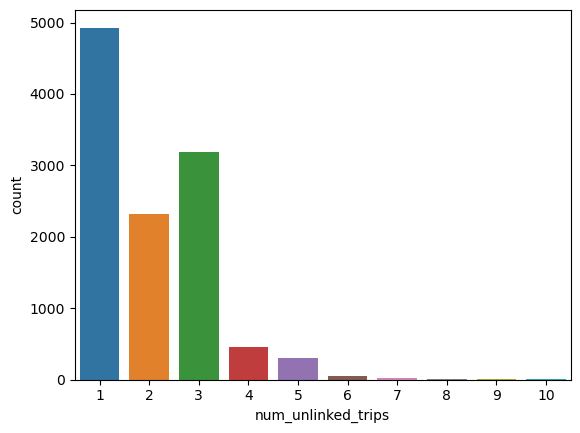

In [321]:
# distribution of leg count
# 3 is reasonably most common -- access, transit, egress
# the majority of trips are also done in 1 trip; this is likely due to the access/egress parts of the trip not being recorded correctly
sns.countplot(x="num_unlinked_trips", data=df[df["mode"] == "Transit"])

In [190]:
# transfer count

In [342]:
# create a transit trip subset and extract trip_ids into a list
transit_trips = df[df["mode"] == "Transit"]
transit_trips["trip_ids"] = transit_trips["trip_id"].apply(lambda x: literal_eval(x))
transit_trips

C:\Users\yianz\AppData\Local\Temp\ipykernel_19512\978881736.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transit_trips["trip_ids"] = transit_trips["trip_id"].apply(lambda x: literal_eval(x))


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,sunset_time,during_daylight,depart_time_dt,time_from_daylight,num_travelers_numeric,num_vehicles_numeric,age_cleaned,disability_cleaned,purpose_cleaned,trip_ids
22,22,1,18114244,1811424402,2,1,1.0,"[1811424402001, 1811424402002, 1811424402003, ...",2018-12-10,Monday,...,16:32:55,False,1900-01-01 06:12:02,5339,1,0,35-44,No,School,"[1811424402001, 1811424402002, 1811424402003, ..."
23,23,1,18114244,1811424402,2,1,2.0,"[1811424402005, 1811424402006, 1811424402007]",2018-12-10,Monday,...,16:32:26,True,1900-01-01 09:32:52,0,1,0,35-44,No,Home,"[1811424402005, 1811424402006, 1811424402007]"
25,25,1,18114244,1811424402,2,1,4.0,"[1811424402009, 1811424402010]",2018-12-10,Monday,...,16:32:58,True,1900-01-01 13:49:17,0,1,0,35-44,No,Errand,"[1811424402009, 1811424402010]"
26,26,1,18114244,1811424402,2,1,5.0,"[1811424402011, 1811424402012, 1811424402013]",2018-12-10,Monday,...,16:33:03,False,1900-01-01 16:10:08,1375,2,0,35-44,No,Home,"[1811424402011, 1811424402012, 1811424402013]"
27,27,1,18114244,1811424402,2,2,6.0,"[1811424402014, 1811424402015, 1811424402016, ...",2018-12-11,Tuesday,...,16:32:53,False,1900-01-01 06:39:09,3767,1,0,35-44,No,School,"[1811424402014, 1811424402015, 1811424402016, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451615,511866,2,22002623,2200262301,1,1,211982.0,"[2200262301004, 2200262301002, 2200262301006]",2022-01-13,Thursday,...,16:54:37,False,1900-01-01 20:00:00,11123,1,0,18-24,No,Home,"[2200262301004, 2200262301002, 2200262301006]"
451644,511897,2,22002658,2200265801,1,1,212076.0,"[2200265801004, 2200265801002, 2200265801005]",2022-01-13,Thursday,...,16:54:06,True,1900-01-01 10:35:00,0,1,0,25-34,No,Work,"[2200265801004, 2200265801002, 2200265801005]"
451674,511932,2,22002672,2200267201,1,1,212138.0,"[2200267201003, 2200267201004, 2200267201005]",2022-01-18,Tuesday,...,17:00:31,False,1900-01-01 20:01:00,10829,2,0,25-34,No,Home,"[2200267201003, 2200267201004, 2200267201005]"
451774,512045,2,22002716,2200271601,1,1,212277.0,"[2200271601003, 2200271601001, 2200271601005]",2022-01-18,Tuesday,...,17:00:05,False,1900-01-01 19:40:00,9595,1,0,65-74,No,Other,"[2200271601003, 2200271601001, 2200271601005]"


In [347]:
def get_num_transfers(trips, wave):
    res = 0
    for trip in trips:
        # count the number of trips whose destination purposes are to change mode
        if wave == 2 and raw_trips.loc[trip]["d_purpose_category"] == 11 or \
            wave == 1 and raw_trips.loc[trip]["d_purpose_category"] == 10:
            res += 1
    return res

In [356]:
# calculate number of transfers
# NOTE: this only approximates the amount of transfers; some linked trips may include egress/access trip as an actual transfer
transit_trips["transfers"] = transit_trips.apply(lambda x: get_num_transfers(x["trip_ids"], x["wave"]), axis=1)

C:\Users\yianz\AppData\Local\Temp\ipykernel_19512\47560241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transit_trips["transfers"] = transit_trips.apply(lambda x: get_num_transfers(x["trip_ids"], x["wave"]), axis=1)


<Axes: xlabel='transfers', ylabel='count'>

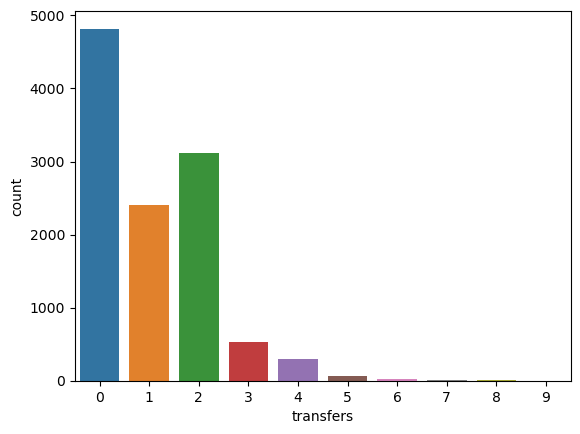

In [357]:
# the most common transfer count is 0; majority of trips have 2 or less transfers
sns.countplot(x="transfers", data=transit_trips)

In [360]:
# 95% of trips are 3 transfers or less
transit_trips["transfers"].describe(percentiles=[0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95])

count    11279.000000
mean         1.066229
std          1.157546
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
80%          2.000000
85%          2.000000
90%          2.000000
95%          3.000000
max          9.000000
Name: transfers, dtype: float64

In [ ]:
# non-transit time

In [365]:
def calc_nontransit_time(trips, wave):
    res = 0
    for trip in trips:
        curr = raw_trips.loc[trip]
        if wave == 1 and curr["mode_type"] not in [1, 3, 4] and (curr["o_purpose_category_imputed"] != 10 or curr["d_purpose_category"] != 10):
            res += curr["duration"]
        elif wave == 2 and curr["mode_type"] not in [12, 13, 14] and (curr["o_purpose_category"] != 11 or curr["d_purpose_category"] != 11):
            res += curr["duration"]
    return res

In [367]:
# NOTE: this is an approximation of non-transit time (minutes)
# some trips exclude the access/egress subtrips (could be negligible), so this is likely an underestiamte
transit_trips["nontransit_time"] = transit_trips.apply(lambda x: calc_nontransit_time(x["trip_ids"], x["wave"]), axis=1)

C:\Users\yianz\AppData\Local\Temp\ipykernel_19512\2322761000.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transit_trips["nontransit_time"] = transit_trips.apply(lambda x: calc_nontransit_time(x["trip_ids"], x["wave"]), axis=1)


In [369]:
# nontransit time (minutes) summary
transit_trips["nontransit_time"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11279.000000
mean         4.973836
std         13.073002
min          0.000000
25%          0.000000
50%          0.000000
75%          7.000000
95%         21.000000
max        537.000000
Name: nontransit_time, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='nontransit_time', ylabel='Density'>)

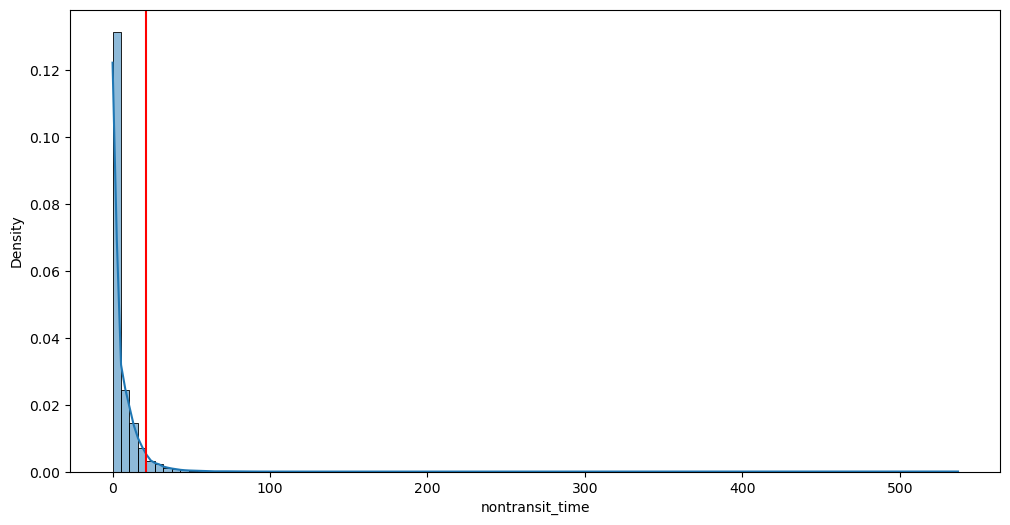

In [370]:
# nontransit time (minutes) density plot
# very left-heavy
plot_density(transit_trips["nontransit_time"])

takeaways

- all these things (including num_unlinked_trips) are approximations using raw trip data
    - can likely be improved but are reasonable approximations right now
    - these approximations are limited by the robustness of the data
- these factors seem to have significant influence on the calculus of individuals 
- vast majority of trips are 2 or less transfers; 95% are less than 3
- nontransit time is bounded by 21 minutes at the 95% percentile
    - very left-heavy

future analysis:
- better approximation techniques
- fix the linked trip logic (go by close time proximity, matching purposes)

### summary

This table indicates the % of car trips that meet each feasibility indicator independently

add % of trips on mode that meet rule & % vmt

| Feasibility indicator                        |      Cutoff            | % of car trips that meet this | 
| :------------------------------------        |   :----:               |         :---:                 |
| bike distance 95th percentile                |    10.5 miles          |           68.9%               |
| walk distance 95th percentile                |    2 miles             |           30.6                |
| transit distance 95th percentile             |   22 miles             |                          |